# 06_surprise_recommendation

Notebook này là **module Recommendation hoàn chỉnh bằng Surprise** cho dự án Olist và được chỉnh để:
- **giữ nguyên tên artifact/output chính** đang được notebook integration / UI chờ đọc,
- **không đổi tên file** và không tác động trực tiếp tới notebook khác,
- tăng độ chặt cho phần **Recommendation** trong rubric và đủ dữ liệu để viết đúng các mục tương ứng trong báo cáo.

## Mục tiêu bám rubric / báo cáo
Notebook này phục vụ trực tiếp cho:
- **Rubric**
  - **2.4 Recommendation**: model hoàn chỉnh, có RMSE, top-N, cold-start handling.
  - **3.1 / 3.3 Utilities & Evaluation**: CV, grid search, bảng metric, summary rõ ràng.
- **Báo cáo cuối kỳ**
  - **VI.4 Recommendation – Surprise**
  - **VII.4 Kết quả thực nghiệm**
  - **VIII.4 Hạn chế**
  - **IX.1 trang Khuyến nghị SP**

## Những gì notebook sẽ làm
1. Đọc `ratings_df` và validate schema.
2. Làm sạch dữ liệu, aggregate về mức `customer_unique_id × product_id × review_score`.
3. Tối ưu ngưỡng lọc sparse để cân bằng giữa **RMSE/MAE** và **coverage**.
4. Huấn luyện và so sánh:
   - `SVD`
   - `KNNWithMeans` *(item-based, dùng để so sánh và hỗ trợ neighbors theo `product_id`)*
5. Đánh giá bằng:
   - Holdout `RMSE`, `MAE`
   - `cross_validate`
   - baseline so sánh
   - ranking metrics (`HitRate@10`, `Recall@10`, `MRR@10`, `NDCG@10`, `CatalogCoverage@10`)
6. Chọn model cuối, train lại trên full filtered data.
7. Sinh asset cho deployment / integration / UI:
   - top-N recommendation theo `customer_unique_id`
   - fallback cho cold-start
   - optional neighbors theo `product_id`
   - deployment bundle + metrics + summary JSON

## Nguyên tắc tương thích với project
- **Không đổi tên các file output lõi** của module Recommendation.
- **Chỉ ghi artifact của chính notebook 06** trong `artifacts/`.
- **Không chỉnh sửa notebook khác**; chỉ tạo đầu ra để notebook 08 / UI dùng tiếp.


## Cell 1: Import thư viện cần thiết

**Mục tiêu**
- Nạp các thư viện cho xử lý dữ liệu, trực quan, Surprise, lưu artifact và hiển thị notebook.

**Lý do**
- Đây là cell nền cho toàn bộ notebook. Nếu import lỗi ở đây thì dừng sớm, tránh chạy nửa chừng gây sai artifact.

**Đầu ra mong đợi**
- Notebook có thể dùng `SVD`, `KNNWithMeans`, `cross_validate`, `GridSearchCV` của Surprise.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import defaultdict
from copy import deepcopy
import json
import time
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

try:
    from surprise import Dataset, Reader, SVD, KNNWithMeans, accuracy
    from surprise.model_selection import train_test_split as surprise_train_test_split
    from surprise.model_selection import cross_validate
    from surprise.model_selection import GridSearchCV as SurpriseGridSearchCV
except Exception as e:
    raise ImportError(
        "Không import được thư viện scikit-surprise. "
        "Hãy cài bằng lệnh: pip install scikit-surprise"
    ) from e

## Cell 2: Khai báo cấu hình chung cho notebook

**Mục tiêu**
- Khai báo đầy đủ đường dẫn, hyperparameter, runtime flags, ngưỡng coverage/ranking warning và tên artifact cần giữ nguyên.

**Cell này quyết định điều gì**
- Notebook có chạy **đúng cấu trúc project hiện tại** hay không.
- Notebook có **giữ tương thích với notebook 08 / UI** hay không.
- Notebook có đủ cờ để bật các phần cần thiết cho **điểm tối đa Recommendation + Utilities** hay không.

**Phần cấu hình quan trọng**
- `FILTER_GRID`: dùng cho filter sweep, tránh fix ngưỡng sparse một cách cảm tính.
- `RUN_SURPRISE_GRID_SEARCH`: bảo đảm có tuning thực sự cho `SVD`.
- `RUN_RANKING_EVAL`: bảo đảm có top-N metrics ngoài `RMSE/MAE`.
- `COVERAGE_*` và `RANKING_*_WARN_THRESHOLD`: dùng để sinh cảnh báo trung thực trong summary/report.
- `MIN_NEIGHBOR_SIMILARITY`: tránh giữ neighbor có similarity bằng 0 như một “neighbor thật”.

**Liên quan rubric / báo cáo**
- Kéo trực tiếp cho **Rubric 2.4 Recommendation** và **3.1 / 3.3 Utilities & Evaluation**.
- Tạo nền để viết đúng phần **VI.4**, **VII.4**, **VIII.4** của báo cáo.


In [2]:
# =========================
# CONFIG
# =========================
def locate_project_base():
    candidates = [Path(".."), Path("."), Path("../..")]
    for base in candidates:
        if (base / "data" / "processed").exists() or (base / "data" / "raw").exists():
            return base
    return Path("..")

BASE_DIR = locate_project_base()
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
ARTIFACT_DIR = BASE_DIR / "artifacts"

MODEL_DIR = ARTIFACT_DIR / "models"
METRIC_DIR = ARTIFACT_DIR / "metrics"
PLOT_DIR = ARTIFACT_DIR / "plots"
PRED_DIR = ARTIFACT_DIR / "predictions"
DATA_ARTIFACT_DIR = ARTIFACT_DIR / "data"

for folder in [MODEL_DIR, METRIC_DIR, PLOT_DIR, PRED_DIR, DATA_ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
TOP_N = 10

DEFAULT_MIN_USER_RATINGS = 2
DEFAULT_MIN_ITEM_RATINGS = 3
MIN_USER_RATINGS = DEFAULT_MIN_USER_RATINGS
MIN_ITEM_RATINGS = DEFAULT_MIN_ITEM_RATINGS

MIN_CANDIDATE_USERS = 500
MIN_CANDIDATE_ITEMS = 150
MIN_CANDIDATE_INTERACTIONS = 1200
FILTER_SWEEP_CV_FOLDS = 3
FILTER_SWEEP_RMSE_TOLERANCE = 0.03
POSITIVE_RATING_THRESHOLD = 4
RATING_SCALE = (1, 5)

COVERAGE_CRITICAL_USER_PCT = 1.0
COVERAGE_CRITICAL_ITEM_PCT = 0.8
COVERAGE_LOW_USER_PCT = 5.0
COVERAGE_LOW_ITEM_PCT = 5.0

RANKING_HITRATE_WARN_THRESHOLD = 0.10
RANKING_NDCG_WARN_THRESHOLD = 0.05
MIN_NEIGHBOR_SIMILARITY = 1e-12


RUN_FILTER_SWEEP = True
RUN_CV_ALL_MODELS = True
RUN_CV_BEST_MODEL = True
RUN_PRODUCT_NEIGHBORS = True
RUN_SURPRISE_GRID_SEARCH = True
RUN_RANKING_EVAL = True

FILTER_GRID = [
    {"min_user_ratings": 2, "min_item_ratings": 2},
    {"min_user_ratings": 2, "min_item_ratings": 3},
    {"min_user_ratings": 2, "min_item_ratings": 4},
    {"min_user_ratings": 3, "min_item_ratings": 2},
    {"min_user_ratings": 3, "min_item_ratings": 3},
]

FILTER_SWEEP_SVD_PARAMS = {
    "n_factors": 40,
    "n_epochs": 20,
    "lr_all": 0.005,
    "reg_all": 0.02,
    "random_state": RANDOM_STATE
}

SVD_BASE_PARAMS = {
    "n_factors": 100,
    "n_epochs": 30,
    "lr_all": 0.005,
    "reg_all": 0.02,
    "random_state": RANDOM_STATE
}

SVD_GRID_PARAM_GRID = {
    "n_factors": [50, 80, 100, 120],
    "n_epochs": [20, 30, 40],
    "lr_all": [0.003, 0.005, 0.007],
    "reg_all": [0.02, 0.05, 0.10]
}

KNN_ITEM_PARAMS = {
    "k": 40,
    "min_k": 5,
    "sim_options": {"name": "cosine", "user_based": False},
    "verbose": False
}

RATINGS_PARQUET = PROCESSED_DIR / "ratings_df.parquet"
RATINGS_CSV = PROCESSED_DIR / "ratings_df.csv"

# QUAN TRỌNG: đồng bộ với output của notebook preprocessing
PROCESSED_PRODUCT_LOOKUP_PARQUET = PROCESSED_DIR / "product_lookup.parquet"
PROCESSED_PRODUCT_LOOKUP_CSV = PROCESSED_DIR / "product_lookup.csv"
ARTIFACT_PRODUCT_LOOKUP_CSV = DATA_ARTIFACT_DIR / "product_lookup.csv"

PRODUCTS_CSV = RAW_DIR / "olist_products_dataset.csv"
CATEGORY_TRANSLATION_CSV = RAW_DIR / "product_category_name_translation.csv"
ORDER_ITEMS_CSV = RAW_DIR / "olist_order_items_dataset.csv"

config_preview_df = pd.DataFrame([
    {"group": "paths", "name": "BASE_DIR", "value": str(BASE_DIR.resolve())},
    {"group": "paths", "name": "PROCESSED_DIR", "value": str(PROCESSED_DIR.resolve())},
    {"group": "paths", "name": "ARTIFACT_DIR", "value": str(ARTIFACT_DIR.resolve())},
    {"group": "runtime", "name": "TEST_SIZE", "value": TEST_SIZE},
    {"group": "runtime", "name": "CV_FOLDS", "value": CV_FOLDS},
    {"group": "runtime", "name": "TOP_N", "value": TOP_N},
    {"group": "filtering", "name": "DEFAULT_MIN_USER_RATINGS", "value": DEFAULT_MIN_USER_RATINGS},
    {"group": "filtering", "name": "DEFAULT_MIN_ITEM_RATINGS", "value": DEFAULT_MIN_ITEM_RATINGS},
    {"group": "filtering", "name": "MIN_CANDIDATE_USERS", "value": MIN_CANDIDATE_USERS},
    {"group": "filtering", "name": "MIN_CANDIDATE_ITEMS", "value": MIN_CANDIDATE_ITEMS},
    {"group": "filtering", "name": "MIN_CANDIDATE_INTERACTIONS", "value": MIN_CANDIDATE_INTERACTIONS},
    {"group": "warnings", "name": "COVERAGE_CRITICAL_USER_PCT", "value": COVERAGE_CRITICAL_USER_PCT},
    {"group": "warnings", "name": "COVERAGE_CRITICAL_ITEM_PCT", "value": COVERAGE_CRITICAL_ITEM_PCT},
    {"group": "warnings", "name": "COVERAGE_LOW_USER_PCT", "value": COVERAGE_LOW_USER_PCT},
    {"group": "warnings", "name": "COVERAGE_LOW_ITEM_PCT", "value": COVERAGE_LOW_ITEM_PCT},
    {"group": "warnings", "name": "RANKING_HITRATE_WARN_THRESHOLD", "value": RANKING_HITRATE_WARN_THRESHOLD},
    {"group": "warnings", "name": "RANKING_NDCG_WARN_THRESHOLD", "value": RANKING_NDCG_WARN_THRESHOLD},
    {"group": "warnings", "name": "MIN_NEIGHBOR_SIMILARITY", "value": MIN_NEIGHBOR_SIMILARITY},
    {"group": "flags", "name": "RUN_FILTER_SWEEP", "value": RUN_FILTER_SWEEP},
    {"group": "flags", "name": "RUN_CV_ALL_MODELS", "value": RUN_CV_ALL_MODELS},
    {"group": "flags", "name": "RUN_SURPRISE_GRID_SEARCH", "value": RUN_SURPRISE_GRID_SEARCH},
    {"group": "flags", "name": "RUN_RANKING_EVAL", "value": RUN_RANKING_EVAL},
    {"group": "flags", "name": "RUN_PRODUCT_NEIGHBORS", "value": RUN_PRODUCT_NEIGHBORS},
])

display(Markdown("### Cấu hình chính"))
display(config_preview_df)

### Cấu hình chính

,group,name,value
0,paths,BASE_DIR,C:\Users\trant\OneDrive\Tài liệu\Documents\U...
1,paths,PROCESSED_DIR,C:\Users\trant\OneDrive\Tài liệu\Documents\U...
2,paths,ARTIFACT_DIR,C:\Users\trant\OneDrive\Tài liệu\Documents\U...
3,runtime,TEST_SIZE,0.2
4,runtime,CV_FOLDS,5
5,runtime,TOP_N,10
6,filtering,DEFAULT_MIN_USER_RATINGS,2
7,filtering,DEFAULT_MIN_ITEM_RATINGS,3
8,filtering,MIN_CANDIDATE_USERS,500
9,filtering,MIN_CANDIDATE_ITEMS,150


## Cell 3: Đọc dữ liệu ratings đầu vào

**Mục tiêu**
- Đọc `ratings_df` từ notebook preprocessing (ưu tiên Parquet, fallback CSV).

**Đầu vào**
- `data/processed/ratings_df.parquet`
- hoặc `data/processed/ratings_df.csv`

**Đầu ra**
- `ratings_raw`: bảng đầu vào thô dùng cho schema validation và clean/aggregate.

**Lưu ý**
- Notebook này **không tự tạo lại `ratings_df`** để tránh lệch logic với notebook preprocessing.

In [3]:
# =========================
# LOAD RATINGS DATA
# =========================
if RATINGS_PARQUET.exists():
    ratings_raw = pd.read_parquet(RATINGS_PARQUET)
    ratings_source = RATINGS_PARQUET
elif RATINGS_CSV.exists():
    ratings_raw = pd.read_csv(RATINGS_CSV)
    ratings_source = RATINGS_CSV
else:
    raise FileNotFoundError(
        "Không tìm thấy ratings_df.parquet hoặc ratings_df.csv trong data/processed"
    )

display(Markdown("### 5 dòng đầu của ratings_df"))
display(ratings_raw.head())

display(Markdown("### Thông tin file đầu vào"))
display(pd.DataFrame([{
    "ratings_source": str(ratings_source),
    "rows": int(ratings_raw.shape[0]),
    "cols": int(ratings_raw.shape[1])
}]))

print("Columns:", list(ratings_raw.columns))

### 5 dòng đầu của ratings_df

,customer_unique_id,product_id,review_score,interaction_count
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,5.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,4.0,1
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,3.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,4.0,1
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,5.0,1


### Thông tin file đầu vào

,ratings_source,rows,cols
0,..\data\processed\ratings_df.parquet,101198,4


Columns: ['customer_unique_id', 'product_id', 'review_score', 'interaction_count']


## Cell 4: Kiểm tra schema dữ liệu

**Mục tiêu**
- Kiểm tra ba cột bắt buộc: `customer_unique_id`, `product_id`, `review_score`.
- Tóm tắt dtype, missing, duplicate user-item.

**Lý do**
- Nếu schema sai từ đầu thì mọi metric về sau đều không đáng tin.
- Đây cũng là phần bằng chứng để giải thích dữ liệu recommendation trong báo cáo.

**Đầu ra**
- `schema_summary`
- các print/check để fail sớm nếu thiếu cột bắt buộc

In [4]:
# =========================
# VALIDATE SCHEMA
# =========================
required_cols = ["customer_unique_id", "product_id", "review_score"]
missing_cols = [c for c in required_cols if c not in ratings_raw.columns]
if missing_cols:
    raise KeyError(f"Thiếu cột bắt buộc trong ratings_df: {missing_cols}")

schema_summary = pd.DataFrame({
    "column": ratings_raw.columns,
    "dtype": ratings_raw.dtypes.astype(str).values,
    "missing_count": ratings_raw.isna().sum().values,
    "missing_pct": (ratings_raw.isna().mean() * 100).round(2).values
})

dup_user_item_raw = ratings_raw.duplicated(subset=["customer_unique_id", "product_id"]).sum()
review_score_summary_df = pd.DataFrame(ratings_raw["review_score"].describe(include="all")).T

display(Markdown("### Schema summary"))
display(schema_summary)

display(Markdown("### review_score describe"))
display(review_score_summary_df)

print("Null customer_unique_id:", int(ratings_raw["customer_unique_id"].isna().sum()))
print("Null product_id        :", int(ratings_raw["product_id"].isna().sum()))
print("Null review_score      :", int(ratings_raw["review_score"].isna().sum()))
print("Duplicate user-item rows:", int(dup_user_item_raw))

### Schema summary

,column,dtype,missing_count,missing_pct
0,customer_unique_id,object,0,0.0
1,product_id,object,0,0.0
2,review_score,float64,0,0.0
3,interaction_count,int64,0,0.0


### review_score describe

,count,mean,std,min,25%,50%,75%,max
review_score,101198.0,4.076242,1.353081,1.0,4.0,5.0,5.0,5.0


Null customer_unique_id: 0
Null product_id        : 0
Null review_score      : 0
Duplicate user-item rows: 0


## Cell 5: Làm sạch và gom nhóm dữ liệu rating

**Mục tiêu**
- Chuẩn hóa kiểu dữ liệu.
- Loại bỏ hàng thiếu `user / item / review_score`.
- Giữ rating trong thang `[1, 5]`.
- Gom duplicate `customer_unique_id × product_id` về **rating trung bình**.

**Lý do**
- Surprise cần rating matrix sạch.
- Việc aggregate duplicate là hợp lý vì cùng một cặp user-item có thể xuất hiện nhiều lần trong dữ liệu gốc.

**Đầu ra**
- `ratings_full`: bảng rating sạch ở mức user-item.

In [5]:
# =========================
# CLEAN & AGGREGATE RATINGS
# - Chuẩn hóa dtype
# - Giữ rating hợp lệ 1..5
# - Gộp duplicate user-item thành rating trung bình
# =========================
ratings_clean = ratings_raw[["customer_unique_id", "product_id", "review_score"]].copy()

ratings_clean["customer_unique_id"] = ratings_clean["customer_unique_id"].astype(str).str.strip()
ratings_clean["product_id"] = ratings_clean["product_id"].astype(str).str.strip()
ratings_clean["review_score"] = pd.to_numeric(ratings_clean["review_score"], errors="coerce")

ratings_clean = ratings_clean.replace({"customer_unique_id": {"": np.nan}, "product_id": {"": np.nan}})
ratings_clean = ratings_clean.dropna(subset=["customer_unique_id", "product_id", "review_score"]).copy()
ratings_clean = ratings_clean[ratings_clean["review_score"].between(RATING_SCALE[0], RATING_SCALE[1])].copy()

ratings_full = (
    ratings_clean
    .groupby(["customer_unique_id", "product_id"], as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        interaction_count=("review_score", "size")
    )
)

ratings_full["review_score"] = ratings_full["review_score"].round(4)

cleaning_summary_df = pd.DataFrame([
    {
        "stage": "ratings_raw",
        "rows": int(len(ratings_raw)),
        "users": int(ratings_raw["customer_unique_id"].nunique(dropna=True)),
        "items": int(ratings_raw["product_id"].nunique(dropna=True))
    },
    {
        "stage": "ratings_clean_valid",
        "rows": int(len(ratings_clean)),
        "users": int(ratings_clean["customer_unique_id"].nunique()),
        "items": int(ratings_clean["product_id"].nunique())
    },
    {
        "stage": "ratings_full_user_item",
        "rows": int(len(ratings_full)),
        "users": int(ratings_full["customer_unique_id"].nunique()),
        "items": int(ratings_full["product_id"].nunique())
    }
])

duplicate_aggregation_df = pd.DataFrame([{
    "duplicate_user_item_raw": int(dup_user_item_raw),
    "mean_interaction_count_after_agg": float(ratings_full["interaction_count"].mean()),
    "max_interaction_count_after_agg": int(ratings_full["interaction_count"].max())
}])

display(Markdown("### Ratings sau khi clean & aggregate"))
display(ratings_full.head())

display(Markdown("### Tóm tắt trước / sau làm sạch"))
display(cleaning_summary_df)

display(Markdown("### Tóm tắt duplicate aggregation"))
display(duplicate_aggregation_df)

### Ratings sau khi clean & aggregate

,customer_unique_id,product_id,review_score,interaction_count
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,5.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,4.0,1
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,3.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,4.0,1
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,5.0,1


### Tóm tắt trước / sau làm sạch

,stage,rows,users,items
0,ratings_raw,101198,94721,32789
1,ratings_clean_valid,101198,94721,32789
2,ratings_full_user_item,101198,94721,32789


### Tóm tắt duplicate aggregation

,duplicate_user_item_raw,mean_interaction_count_after_agg,max_interaction_count_after_agg
0,0,1.0,1


## Cell 6: Lọc user và item quá thưa

**Mục tiêu**
- Giảm sparsity trước khi collaborative filtering.
- Thử nhiều ngưỡng lọc để chọn cấu hình cân bằng giữa:
  - chất lượng dự đoán (`RMSE`, `MAE`)
  - độ phủ người dùng / sản phẩm
  - số interactions còn lại

**Lý do**
- Điểm yếu lớn nhất của notebook Recommendation thường không nằm ở code model mà nằm ở **filter quá mạnh làm coverage sụt sâu**.
- Cell này được viết để chọn ngưỡng có cơ sở thay vì fix cứng một cặp tham số.

**Đầu ra**
- `ratings_model_df`
- `filter_search_df`
- `best_filter_config`

In [6]:
# =========================
# FILTER SPARSE USERS / ITEMS
# - chọn ngưỡng có cơ sở thay vì fix cứng
# =========================
def filter_sparse_interactions(df, min_user_ratings=2, min_item_ratings=5, max_iter=20):
    out = df.copy()

    for _ in range(max_iter):
        before_rows = len(out)

        user_counts = out.groupby("customer_unique_id")["product_id"].size()
        valid_users = user_counts[user_counts >= min_user_ratings].index
        out = out[out["customer_unique_id"].isin(valid_users)].copy()

        item_counts = out.groupby("product_id")["customer_unique_id"].size()
        valid_items = item_counts[item_counts >= min_item_ratings].index
        out = out[out["product_id"].isin(valid_items)].copy()

        if len(out) == before_rows:
            break

    return out

def matrix_stats(df, stage_name):
    users = df["customer_unique_id"].nunique()
    items = df["product_id"].nunique()
    interactions = len(df)
    density = interactions / (users * items) if users > 0 and items > 0 else np.nan
    sparsity = 1 - density if pd.notna(density) else np.nan

    return {
        "stage": stage_name,
        "users": int(users),
        "items": int(items),
        "interactions": int(interactions),
        "density": round(float(density), 8) if pd.notna(density) else np.nan,
        "sparsity": round(float(sparsity), 8) if pd.notna(sparsity) else np.nan
    }

def evaluate_filter_candidate(filtered_df, min_user_ratings, min_item_ratings):
    row = matrix_stats(
        filtered_df,
        stage_name=f"user>={min_user_ratings} | item>={min_item_ratings}"
    )
    row["min_user_ratings"] = int(min_user_ratings)
    row["min_item_ratings"] = int(min_item_ratings)
    row["user_coverage_pct"] = round(
        filtered_df["customer_unique_id"].nunique() / ratings_full["customer_unique_id"].nunique() * 100, 2
    ) if len(filtered_df) > 0 else 0.0
    row["item_coverage_pct"] = round(
        filtered_df["product_id"].nunique() / ratings_full["product_id"].nunique() * 100, 2
    ) if len(filtered_df) > 0 else 0.0
    row["eligible"] = False
    row["skip_reason"] = ""
    row["cv_rmse_mean"] = np.nan
    row["cv_mae_mean"] = np.nan
    row["cv_rmse_std"] = np.nan
    row["cv_mae_std"] = np.nan

    if len(filtered_df) == 0:
        row["skip_reason"] = "filtered_df_empty"
        return row

    if (
        filtered_df["customer_unique_id"].nunique() < MIN_CANDIDATE_USERS
        or filtered_df["product_id"].nunique() < MIN_CANDIDATE_ITEMS
        or len(filtered_df) < MIN_CANDIDATE_INTERACTIONS
    ):
        row["skip_reason"] = "below_candidate_thresholds"
        return row

    try:
        candidate_reader = Reader(rating_scale=RATING_SCALE)
        candidate_surprise_df = filtered_df[["customer_unique_id", "product_id", "review_score"]].copy()
        candidate_data = Dataset.load_from_df(candidate_surprise_df, candidate_reader)

        cv_scores = cross_validate(
            SVD(**FILTER_SWEEP_SVD_PARAMS),
            candidate_data,
            measures=["RMSE", "MAE"],
            cv=FILTER_SWEEP_CV_FOLDS,
            verbose=False,
            n_jobs=1
        )

        row["cv_rmse_mean"] = float(np.mean(cv_scores["test_rmse"]))
        row["cv_mae_mean"] = float(np.mean(cv_scores["test_mae"]))
        row["cv_rmse_std"] = float(np.std(cv_scores["test_rmse"]))
        row["cv_mae_std"] = float(np.std(cv_scores["test_mae"]))
        row["eligible"] = True
        row["skip_reason"] = ""
    except Exception as e:
        row["skip_reason"] = f"cv_failed: {str(e)[:120]}"

    return row

filter_search_rows = []

if RUN_FILTER_SWEEP:
    for cfg in FILTER_GRID:
        filtered_candidate = filter_sparse_interactions(
            ratings_full,
            min_user_ratings=cfg["min_user_ratings"],
            min_item_ratings=cfg["min_item_ratings"]
        )
        filter_search_rows.append(
            evaluate_filter_candidate(
                filtered_candidate,
                min_user_ratings=cfg["min_user_ratings"],
                min_item_ratings=cfg["min_item_ratings"]
            )
        )
else:
    filtered_candidate = filter_sparse_interactions(
        ratings_full,
        min_user_ratings=MIN_USER_RATINGS,
        min_item_ratings=MIN_ITEM_RATINGS
    )
    filter_search_rows.append(
        evaluate_filter_candidate(
            filtered_candidate,
            min_user_ratings=MIN_USER_RATINGS,
            min_item_ratings=MIN_ITEM_RATINGS
        )
    )

filter_search_df = pd.DataFrame(filter_search_rows)

best_filter_config = {
    "min_user_ratings": int(MIN_USER_RATINGS),
    "min_item_ratings": int(MIN_ITEM_RATINGS),
    "selection_reason": "default_config_no_filter_search"
}

if not filter_search_df.empty:
    filter_search_df = filter_search_df.sort_values(
        ["eligible", "cv_rmse_mean", "cv_mae_mean", "interactions", "user_coverage_pct", "item_coverage_pct"],
        ascending=[False, True, True, False, False, False]
    ).reset_index(drop=True)

    eligible_filter_df = filter_search_df[filter_search_df["eligible"]].copy()

    if not eligible_filter_df.empty:
        best_rmse = float(eligible_filter_df.iloc[0]["cv_rmse_mean"])
        near_best_df = eligible_filter_df[
            eligible_filter_df["cv_rmse_mean"] <= best_rmse + FILTER_SWEEP_RMSE_TOLERANCE
        ].copy()

        near_best_df = near_best_df.sort_values(
            ["interactions", "user_coverage_pct", "item_coverage_pct", "cv_rmse_mean", "cv_mae_mean"],
            ascending=[False, False, False, True, True]
        ).reset_index(drop=True)

        selected_row = near_best_df.iloc[0].to_dict()
        MIN_USER_RATINGS = int(selected_row["min_user_ratings"])
        MIN_ITEM_RATINGS = int(selected_row["min_item_ratings"])
        best_filter_config = {
            "min_user_ratings": MIN_USER_RATINGS,
            "min_item_ratings": MIN_ITEM_RATINGS,
            "selection_reason": (
                "within_rmse_tolerance_then_maximize_interactions_and_coverage"
            ),
            "cv_rmse_mean": float(selected_row["cv_rmse_mean"]),
            "cv_mae_mean": float(selected_row["cv_mae_mean"]),
            "user_coverage_pct": float(selected_row["user_coverage_pct"]),
            "item_coverage_pct": float(selected_row["item_coverage_pct"]),
            "interactions": int(selected_row["interactions"])
        }

ratings_model_df = filter_sparse_interactions(
    ratings_full,
    min_user_ratings=MIN_USER_RATINGS,
    min_item_ratings=MIN_ITEM_RATINGS
)

matrix_compare_df = pd.DataFrame([
    matrix_stats(ratings_full, "ratings_full"),
    matrix_stats(ratings_model_df, "ratings_model_df")
])

filter_search_path = METRIC_DIR / "surprise_filter_search.csv"
filter_search_df.to_csv(filter_search_path, index=False)

display(Markdown("### Matrix stats trước / sau filter"))
display(matrix_compare_df)

display(Markdown("### Filter sweep results"))
display(filter_search_df)

display(Markdown("### Best filter config"))
display(pd.DataFrame([best_filter_config]))

print("MIN_USER_RATINGS (final):", MIN_USER_RATINGS)
print("MIN_ITEM_RATINGS (final):", MIN_ITEM_RATINGS)
print("Đã lưu:", filter_search_path)

### Matrix stats trước / sau filter

,stage,users,items,interactions,density,sparsity
0,ratings_full,94721,32789,101198,0.000033,0.999967
1,ratings_model_df,1272,713,2688,0.002964,0.997036


### Filter sweep results

,stage,users,items,interactions,density,sparsity,min_user_ratings,min_item_ratings,user_coverage_pct,item_coverage_pct,eligible,skip_reason,cv_rmse_mean,cv_mae_mean,cv_rmse_std,cv_mae_std
0,user>=2 | item>=2,1272,713,2688,0.002964,0.997036,2,2,1.34,2.17,True,,1.513480,1.325636,0.021700,0.018166
1,user>=2 | item>=3,593,178,1244,0.011785,0.988215,2,3,0.63,0.54,True,,1.555358,1.379849,0.021415,0.016254
2,user>=2 | item>=4,406,81,833,0.025330,0.974670,2,4,0.43,0.25,False,below_candidate_thresholds,NaN,NaN,NaN,NaN
3,user>=3 | item>=2,26,31,81,0.100496,0.899504,3,2,0.03,0.09,False,below_candidate_thresholds,NaN,NaN,NaN,NaN
4,user>=3 | item>=3,11,11,35,0.289256,0.710744,3,3,0.01,0.03,False,below_candidate_thresholds,NaN,NaN,NaN,NaN


### Best filter config

,min_user_ratings,min_item_ratings,selection_reason,cv_rmse_mean,cv_mae_mean,user_coverage_pct,item_coverage_pct,interactions
0,2,2,within_rmse_tolerance_then_maximize_interactio...,1.51348,1.325636,1.34,2.17,2688


MIN_USER_RATINGS (final): 2
MIN_ITEM_RATINGS (final): 2
Đã lưu: ..\artifacts\metrics\surprise_filter_search.csv


## Cell 7: Đánh giá mức độ coverage sau filtering

**Mục tiêu**
- Đo phần trăm user/item còn giữ lại sau bước lọc sparse.
- Sinh cảnh báo rõ ràng nếu coverage quá thấp.

**Lý do**
- Đây là thông tin bắt buộc phải nói thật trong báo cáo để tránh overclaim chất lượng recommender.

**Đầu ra**
- `coverage_df`
- `coverage_warning_df`
- `coverage_warning`

In [7]:
coverage_df = pd.DataFrame([{
    "users_full": int(ratings_full["customer_unique_id"].nunique()),
    "users_model": int(ratings_model_df["customer_unique_id"].nunique()),
    "items_full": int(ratings_full["product_id"].nunique()),
    "items_model": int(ratings_model_df["product_id"].nunique()),
    "interactions_full": int(len(ratings_full)),
    "interactions_model": int(len(ratings_model_df)),
    "user_coverage_pct": round(
        ratings_model_df["customer_unique_id"].nunique() / ratings_full["customer_unique_id"].nunique() * 100, 2
    ),
    "item_coverage_pct": round(
        ratings_model_df["product_id"].nunique() / ratings_full["product_id"].nunique() * 100, 2
    ),
    "interaction_retention_pct": round(
        len(ratings_model_df) / len(ratings_full) * 100, 2
    )
}])

user_cov = float(coverage_df.iloc[0]["user_coverage_pct"])
item_cov = float(coverage_df.iloc[0]["item_coverage_pct"])
interaction_cov = float(coverage_df.iloc[0]["interaction_retention_pct"])

coverage_warning = None
coverage_status = "acceptable"

if user_cov < COVERAGE_CRITICAL_USER_PCT or item_cov < COVERAGE_CRITICAL_ITEM_PCT:
    coverage_status = "critical"
    coverage_warning = (
        f"Coverage rất thấp: users={user_cov:.2f}% | items={item_cov:.2f}% | "
        f"interactions={interaction_cov:.2f}%. Recommendation chỉ phản ánh một tập con rất nhỏ của hệ Olist."
    )
elif user_cov < COVERAGE_LOW_USER_PCT or item_cov < COVERAGE_LOW_ITEM_PCT:
    coverage_status = "low"
    coverage_warning = (
        f"Coverage thấp: users={user_cov:.2f}% | items={item_cov:.2f}% | "
        f"interactions={interaction_cov:.2f}%. Cần ghi rõ hạn chế này trong báo cáo."
    )
else:
    coverage_warning = (
        f"Coverage chấp nhận được: users={user_cov:.2f}% | items={item_cov:.2f}% | "
        f"interactions={interaction_cov:.2f}%."
    )

coverage_warning_df = pd.DataFrame([{
    "coverage_status": coverage_status,
    "user_coverage_pct": user_cov,
    "item_coverage_pct": item_cov,
    "interaction_retention_pct": interaction_cov,
    "warning": coverage_warning
}])

display(Markdown("### Coverage sau filtering"))
display(coverage_df)

display(Markdown("### Coverage warning"))
display(coverage_warning_df)


### Coverage sau filtering

,users_full,users_model,items_full,items_model,interactions_full,interactions_model,user_coverage_pct,item_coverage_pct,interaction_retention_pct
0,94721,1272,32789,713,101198,2688,1.34,2.17,2.66


### Coverage warning

,coverage_status,user_coverage_pct,item_coverage_pct,interaction_retention_pct,warning
0,low,1.34,2.17,2.66,Coverage thấp: users=1.34% | items=2.17% | int...


## Cell 8: Chẩn đoán nhanh rating matrix

**Mục tiêu**
- Kiểm tra phân phối rating sau filtering.
- Xem user/item nào có nhiều tương tác nhất.
- Có thêm thống kê degree để hiểu mức độ thưa của ma trận.

**Lý do**
- Cell này giúp giải thích vì sao SVD/KNN có kết quả như vậy, và là phần rất hữu ích cho discussion.

### Phân phối review_score - ratings_full

review_score
1.0000    11756
1.5000        4
1.5714        1
1.6667        3
2.0000     3338
2.2000        1
2.3333        4
2.5000       13
3.0000     8451
3.2857        1
3.4000        1
3.5000       17
3.5556        1
3.6667        5
3.7500        1
4.0000    19408
4.2500        1
4.3333        2
4.4286        1
4.5000       38
4.6667        3
4.7500        1
5.0000    58147
Name: count, dtype: int64

### Top 10 users có nhiều tương tác nhất

,customer_unique_id,rating_count
847,acea6bd29b8c1e3c6a8b266a8fb4475e,6
886,b2bd387fdc3cf05931f0f897d607dc88,5
1102,df9d2585c3e7b4f8904b1933e5ad2c7c,4
895,b471f6779ed58f5dbcf786cf9842067a,4
415,595e38fad1949e25468ad1c7c06924d0,4
934,bbf65e7823171a84e70a495dd6c34ceb,4
490,692074726678229d1fe1887a9f0abb14,4
509,6ba5b2dcb81470882212da717a171539,4
251,362928c8cd61df2e6951751dffb4be85,4
1050,d65c32925d7e29eb440266a1eba9a10f,4


### Top 10 items có nhiều rating nhất

,product_id,rating_count
156,36f60d45225e60c7da4558b070ce4b60,74
632,e53e557d5a159f5aa2c5e995dfdf244b,52
419,99a4788cb24856965c36a24e339b6058,47
165,389d119b48cf3043d311335e499d9c6b,37
58,154e7e31ebfa092203795c972e5804a6,35
151,35afc973633aaeb6b877ff57b2793310,34
193,422879e10f46682990de24d770e7f83d,31
235,53759a2ecddad2bb87a079a1f1519f73,29
154,368c6c730842d78016ad823897a372db,27
183,3f14d740544f37ece8a9e7bc8349797e,26


### User degree summary

,count,mean,std,min,25%,50%,75%,max
rating_count,1272.0,2.113208,0.380172,2.0,2.0,2.0,2.0,6.0


### Item degree summary

,count,mean,std,min,25%,50%,75%,max
rating_count,713.0,3.769986,5.156576,2.0,2.0,2.0,4.0,74.0


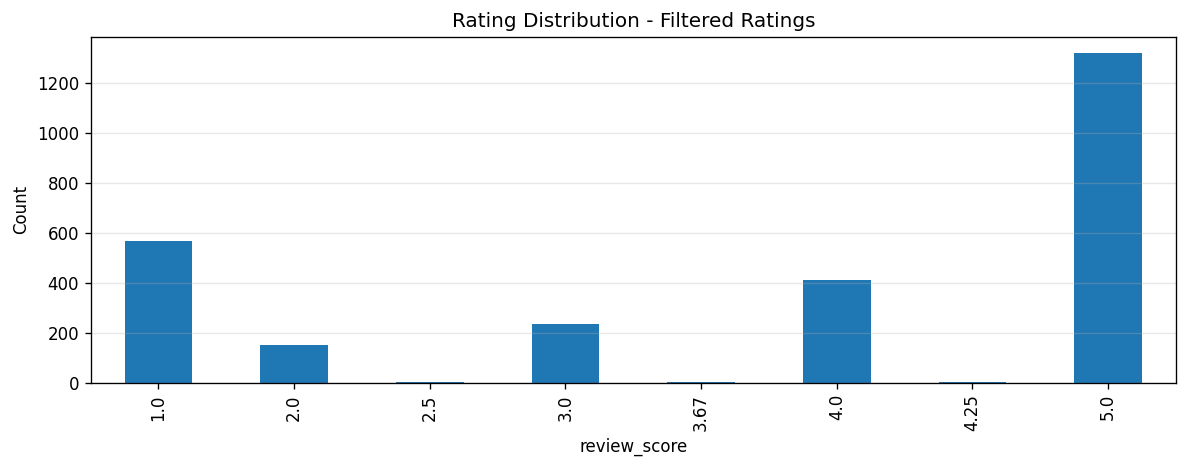

Đã lưu: ..\artifacts\plots\surprise_rating_distribution_filtered.png


In [8]:
# =========================
# MINI DIAGNOSTICS CHO RATING MATRIX
# =========================
display(Markdown("### Phân phối review_score - ratings_full"))
display(ratings_full["review_score"].value_counts().sort_index())

user_degree_df = (
    ratings_model_df.groupby("customer_unique_id")["product_id"]
    .size()
    .reset_index(name="rating_count")
    .sort_values("rating_count", ascending=False)
)

item_degree_df = (
    ratings_model_df.groupby("product_id")["customer_unique_id"]
    .size()
    .reset_index(name="rating_count")
    .sort_values("rating_count", ascending=False)
)

top_users = user_degree_df.head(10).copy()
top_items = item_degree_df.head(10).copy()

user_degree_summary_df = pd.DataFrame(user_degree_df["rating_count"].describe()).T
item_degree_summary_df = pd.DataFrame(item_degree_df["rating_count"].describe()).T

display(Markdown("### Top 10 users có nhiều tương tác nhất"))
display(top_users)

display(Markdown("### Top 10 items có nhiều rating nhất"))
display(top_items)

display(Markdown("### User degree summary"))
display(user_degree_summary_df)

display(Markdown("### Item degree summary"))
display(item_degree_summary_df)

rating_dist = ratings_model_df["review_score"].round(2).value_counts().sort_index()

plt.figure(figsize=(10, 4))
rating_dist.plot(kind="bar")
plt.title("Rating Distribution - Filtered Ratings")
plt.xlabel("review_score")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
rating_dist_plot_path = PLOT_DIR / "surprise_rating_distribution_filtered.png"
plt.savefig(rating_dist_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu:", rating_dist_plot_path)

## Cell 9: Xây dựng bảng product lookup

**Mục tiêu**
- Tạo bảng lookup cho `product_id` để enrich recommendation output.

**Ưu tiên logic**
1. Ưu tiên dùng output từ notebook preprocessing (`product_lookup.parquet/csv`) để đồng bộ với toàn project.
2. Chỉ rebuild từ raw CSV khi artifact processed không có.

**Đầu ra**
- `product_lookup`
- file artifact: `artifacts/data/product_lookup.csv`

In [9]:
# =========================
# BUILD PRODUCT LOOKUP (ưu tiên dùng artifact từ notebook 02)
# =========================
def build_product_lookup_from_raw():
    lookup = (
        ratings_full.groupby("product_id", as_index=False)
        .agg(
            rating_mean=("review_score", "mean"),
            rating_count=("review_score", "size")
        )
    )

    if PRODUCTS_CSV.exists():
        products = pd.read_csv(PRODUCTS_CSV)

        keep_product_cols = ["product_id", "product_category_name"]
        keep_product_cols = [c for c in keep_product_cols if c in products.columns]
        products = products[keep_product_cols].copy()

        if CATEGORY_TRANSLATION_CSV.exists() and "product_category_name" in products.columns:
            category_translation = pd.read_csv(CATEGORY_TRANSLATION_CSV)
            products = products.merge(
                category_translation,
                on="product_category_name",
                how="left"
            )
            products["product_category_name_english"] = (
                products["product_category_name_english"]
                .fillna(products["product_category_name"])
                .fillna("unknown")
            )
        else:
            products["product_category_name_english"] = products.get("product_category_name", "unknown")

        lookup = lookup.merge(
            products[["product_id", "product_category_name_english"]].drop_duplicates("product_id"),
            on="product_id",
            how="left"
        )

    if ORDER_ITEMS_CSV.exists():
        order_items = pd.read_csv(ORDER_ITEMS_CSV)

        if {"product_id", "price", "order_id"}.issubset(order_items.columns):
            item_price = (
                order_items.groupby("product_id", as_index=False)
                .agg(
                    avg_price=("price", "mean"),
                    purchase_count=("order_id", "size")
                )
            )
            lookup = lookup.merge(item_price, on="product_id", how="left")

    return lookup

def finalize_product_lookup(lookup_df):
    lookup = lookup_df.copy()

    if "product_id" not in lookup.columns:
        raise KeyError("product_lookup phải có cột 'product_id'")

    lookup["product_id"] = lookup["product_id"].astype(str).str.strip()
    lookup = lookup.replace({"product_id": {"": np.nan}})
    lookup = lookup.dropna(subset=["product_id"]).copy()

    numeric_cols = ["rating_mean", "rating_count", "avg_price", "purchase_count"]
    for col in numeric_cols:
        if col in lookup.columns:
            lookup[col] = pd.to_numeric(lookup[col], errors="coerce")

    if "product_category_name_english" not in lookup.columns:
        lookup["product_category_name_english"] = "unknown"

    lookup["product_category_name_english"] = (
        lookup["product_category_name_english"]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .replace("", "unknown")
    )

    sort_cols = [c for c in ["rating_count", "rating_mean", "purchase_count", "product_id"] if c in lookup.columns]
    ascending = [False if c != "product_id" else True for c in sort_cols]

    if sort_cols:
        lookup = lookup.sort_values(sort_cols, ascending=ascending)

    lookup = lookup.drop_duplicates(subset=["product_id"], keep="first").reset_index(drop=True)

    preferred_order = [
        "product_id",
        "product_category_name_english",
        "rating_mean",
        "rating_count",
        "avg_price",
        "purchase_count"
    ]
    existing_cols = [c for c in preferred_order if c in lookup.columns]
    remaining_cols = [c for c in lookup.columns if c not in existing_cols]
    lookup = lookup[existing_cols + remaining_cols]

    return lookup

if PROCESSED_PRODUCT_LOOKUP_PARQUET.exists():
    product_lookup = pd.read_parquet(PROCESSED_PRODUCT_LOOKUP_PARQUET)
    product_lookup_source = str(PROCESSED_PRODUCT_LOOKUP_PARQUET)
elif PROCESSED_PRODUCT_LOOKUP_CSV.exists():
    product_lookup = pd.read_csv(PROCESSED_PRODUCT_LOOKUP_CSV)
    product_lookup_source = str(PROCESSED_PRODUCT_LOOKUP_CSV)
else:
    product_lookup = build_product_lookup_from_raw()
    product_lookup_source = "rebuilt_from_raw"

product_lookup = finalize_product_lookup(product_lookup)

product_lookup_path = ARTIFACT_PRODUCT_LOOKUP_CSV
product_lookup.to_csv(product_lookup_path, index=False)

display(Markdown("### Product lookup sample"))
display(product_lookup.head())

display(Markdown("### Product lookup diagnostics"))
display(pd.DataFrame([{
    "source": product_lookup_source,
    "rows": int(len(product_lookup)),
    "unique_product_id": int(product_lookup["product_id"].nunique()),
    "duplicate_product_id": int(product_lookup.duplicated("product_id").sum()),
    "unknown_category_rows": int(product_lookup["product_category_name_english"].eq("unknown").sum())
}]))

print("Đã lưu:", product_lookup_path)

### Product lookup sample

,product_id,product_category_name_english,rating_mean,rating_count,avg_price,purchase_count
0,99a4788cb24856965c36a24e339b6058,bed_bath_table,3.914661,457,88.167131,488
1,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,4.098131,428,71.364137,527
2,422879e10f46682990de24d770e7f83d,garden_tools,4.140964,348,54.911612,484
3,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,4.236677,319,137.651633,343
4,389d119b48cf3043d311335e499d9c6b,garden_tools,4.181230,309,54.695383,392


### Product lookup diagnostics

,source,rows,unique_product_id,duplicate_product_id,unknown_category_rows
0,..\data\processed\product_lookup.parquet,32789,32789,0,605


Đã lưu: ..\artifacts\data\product_lookup.csv


## Cell 10: Xây dựng bảng fallback theo độ phổ biến

**Mục tiêu**
- Tạo danh sách sản phẩm fallback cho:
  - cold-start user
  - unknown product
  - các trường hợp cần top-up recommendation

**Cách làm**
- Dùng `weighted_rating` kết hợp:
  - `rating_mean`
  - `rating_count`
  - (nếu có) `purchase_count`

**Lý do**
- Rubric Recommendation mức cao nhất yêu cầu có **cold-start handling**.

### Top 15 fallback products

,product_id,product_category_name_english,rating_mean,rating_count,avg_price,purchase_count,weighted_rating
0,73326828aa5efe1ba096223de496f596,food,4.849057,53,82.611481,54,4.722837
1,3e4176d545618ed02f382a3057de32b4,luggage_accessories,4.958333,24,132.379583,24,4.692316
2,6a8631b72a2f8729b91514db87e771c0,electronics,4.736842,57,26.641935,62,4.634907
3,f7f59e6186e10983a061ac7bdb3494d6,housewares,4.814815,27,34.900000,39,4.609156
4,62c89abe1afe3a23c17765d462718a4c,perfumery,4.937500,16,244.812500,16,4.597645
5,574597aaf385996112490308e37399ce,housewares,4.826087,23,49.000000,24,4.592084
6,2722b7e5f68e776d18fe901638034e54,health_beauty,5.000000,13,28.669231,13,4.588642
7,e7f85e7f0203b7b95cc1b4c21b4b070c,cool_stuff,4.850000,20,263.907391,23,4.584625
8,475e8a9ddbebf13af503d1c7eccadb1a,office_furniture,4.882353,17,136.163158,19,4.575510
9,f8b624d4e475bb8d1bddf1b65c6a64f6,housewares,4.690476,42,179.000000,42,4.568053


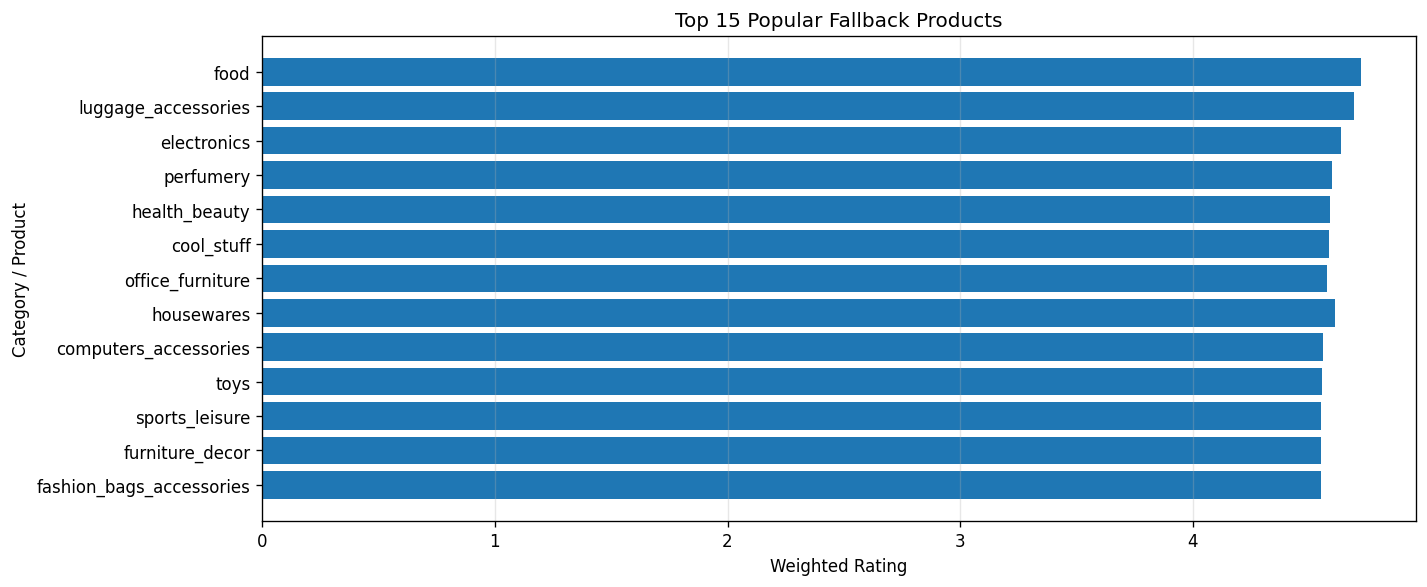

Đã lưu: ..\artifacts\predictions\popular_products_fallback.csv
Đã lưu: ..\artifacts\plots\surprise_popularity_fallback_top15.png


In [10]:
# =========================
# BUILD POPULARITY FALLBACK TABLE
# - Dùng cho cold-start user / unknown item / top-up recommendation
# =========================
fallback_base = product_lookup.copy()

required_fallback_cols = ["product_id", "rating_mean", "rating_count"]
missing_fallback_cols = [c for c in required_fallback_cols if c not in fallback_base.columns]
if missing_fallback_cols:
    raise KeyError(f"product_lookup thiếu cột bắt buộc để build fallback: {missing_fallback_cols}")

fallback_base["rating_mean"] = pd.to_numeric(fallback_base["rating_mean"], errors="coerce")
fallback_base["rating_count"] = pd.to_numeric(fallback_base["rating_count"], errors="coerce").fillna(0)

global_mean = fallback_base["rating_mean"].dropna().mean()
if pd.isna(global_mean):
    global_mean = 0.0

m = max(10, int(fallback_base["rating_count"].quantile(0.75))) if len(fallback_base) > 0 else 10

fallback_base["weighted_rating"] = (
    (fallback_base["rating_count"] / (fallback_base["rating_count"] + m)) * fallback_base["rating_mean"].fillna(global_mean)
    + (m / (fallback_base["rating_count"] + m)) * global_mean
)

sort_cols = ["weighted_rating", "rating_count"]
ascending = [False, False]

if "purchase_count" in fallback_base.columns:
    fallback_base["purchase_count"] = pd.to_numeric(fallback_base["purchase_count"], errors="coerce")
    sort_cols.append("purchase_count")
    ascending.append(False)

popularity_fallback = (
    fallback_base
    .sort_values(sort_cols, ascending=ascending)
    .drop_duplicates("product_id")
    .reset_index(drop=True)
)

preferred_cols = [
    "product_id",
    "product_category_name_english",
    "rating_mean",
    "rating_count",
    "avg_price",
    "purchase_count",
    "weighted_rating"
]
existing_cols = [c for c in preferred_cols if c in popularity_fallback.columns]
remaining_cols = [c for c in popularity_fallback.columns if c not in existing_cols]
popularity_fallback = popularity_fallback[existing_cols + remaining_cols]

popularity_fallback_path = PRED_DIR / "popular_products_fallback.csv"
popularity_fallback.to_csv(popularity_fallback_path, index=False)

display(Markdown("### Top 15 fallback products"))
display(popularity_fallback.head(15))

plt.figure(figsize=(12, 5))
fallback_plot_df = popularity_fallback.head(15).copy()
fallback_plot_df["label"] = fallback_plot_df["product_category_name_english"].astype(str)
fallback_plot_df["label"] = np.where(
    fallback_plot_df["label"].eq("unknown"),
    fallback_plot_df["product_id"].str[:8],
    fallback_plot_df["label"]
)
fallback_plot_df = fallback_plot_df.iloc[::-1]

plt.barh(fallback_plot_df["label"], fallback_plot_df["weighted_rating"])
plt.title("Top 15 Popular Fallback Products")
plt.xlabel("Weighted Rating")
plt.ylabel("Category / Product")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

fallback_plot_path = PLOT_DIR / "surprise_popularity_fallback_top15.png"
plt.savefig(fallback_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu:", popularity_fallback_path)
print("Đã lưu:", fallback_plot_path)

## Cell 11: Tạo Surprise dataset

**Mục tiêu**
- Chuyển `ratings_model_df` sang định dạng Surprise (`Reader + Dataset.load_from_df`).

**Đầu ra**
- `reader`
- `surprise_df`
- `surprise_data`

**Lưu ý**
- Đây là điểm nối giữa phần preprocessing của dự án và phần modeling Recommendation.

In [11]:
# =========================
# BUILD SURPRISE DATASET
# =========================
reader = Reader(rating_scale=RATING_SCALE)

surprise_df = ratings_model_df[["customer_unique_id", "product_id", "review_score"]].copy()
surprise_data = Dataset.load_from_df(surprise_df, reader)

print("Filtered surprise_df shape:", surprise_df.shape)
print("Users:", int(surprise_df["customer_unique_id"].nunique()))
print("Items:", int(surprise_df["product_id"].nunique()))

Filtered surprise_df shape: (2688, 3)
Users: 1272
Items: 713


## Cell 12: Chia train/test cho Surprise

**Mục tiêu**
- Tạo holdout split để đánh giá khách quan bằng `RMSE`, `MAE`.
- Giữ random seed cố định để kết quả có thể tái lập.

**Lý do**
- Holdout metrics là bằng chứng chính cho bảng kết quả phần Recommendation trong báo cáo.

In [12]:
# =========================
# TRAIN / TEST SPLIT (SURPRISE)
# =========================
trainset, testset = surprise_train_test_split(
    surprise_data,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

positive_test_ratio = np.mean([1 if r_ui >= POSITIVE_RATING_THRESHOLD else 0 for _, _, r_ui in testset]) if len(testset) > 0 else np.nan

split_summary_df = pd.DataFrame([{
    "trainset_users": int(trainset.n_users),
    "trainset_items": int(trainset.n_items),
    "trainset_ratings": int(trainset.n_ratings),
    "testset_size": int(len(testset)),
    "positive_test_ratio": round(float(positive_test_ratio), 4) if pd.notna(positive_test_ratio) else np.nan
}])

display(Markdown("### Train / test split summary"))
display(split_summary_df)

### Train / test split summary

,trainset_users,trainset_items,trainset_ratings,testset_size,positive_test_ratio
0,1225,695,2150,538,0.6431


## Cell 13: Khai báo factory cho các mô hình recommendation

**Mục tiêu**
- Khai báo factory để có thể tạo model nhất quán ở nhiều bước:
  - holdout evaluation
  - CV
  - tuning
  - retrain full data
  - deployment

**Model dùng trong notebook**
- `SVD` (ứng viên chính)
- `KNNWithMeans` item-based (model so sánh + hỗ trợ product-neighbors)

**Lý do**
- Bám đúng yêu cầu của file môn học và báo cáo mẫu: Recommendation bằng Surprise với `SVD` hoặc `KNNWithMeans`.

In [13]:
# =========================
# DEFINE MODEL FACTORIES
# =========================
selected_svd_params = deepcopy(SVD_BASE_PARAMS)
selected_knn_params = deepcopy(KNN_ITEM_PARAMS)
tuned_svd_params = None

def make_factory(constructor, params):
    params_copy = deepcopy(params)
    return lambda constructor=constructor, params_copy=params_copy: constructor(**params_copy)

def rebuild_model_factories():
    factories = {
        "SVD": make_factory(SVD, selected_svd_params),
        "KNNWithMeans_item_based": make_factory(KNNWithMeans, selected_knn_params),
    }
    if tuned_svd_params is not None:
        factories["SVD_TUNED"] = make_factory(SVD, tuned_svd_params)
    return factories

def get_model_params_by_name(model_name):
    if model_name == "SVD":
        return deepcopy(selected_svd_params)
    if model_name == "KNNWithMeans_item_based":
        return deepcopy(selected_knn_params)
    if model_name == "SVD_TUNED" and tuned_svd_params is not None:
        return deepcopy(tuned_svd_params)
    return {}

model_factories = rebuild_model_factories()

config_rows = [
    {"model": "SVD", **selected_svd_params},
    {"model": "KNNWithMeans_item_based", **{
        "k": selected_knn_params["k"],
        "min_k": selected_knn_params["min_k"],
        "sim_name": selected_knn_params["sim_options"]["name"],
        "user_based": selected_knn_params["sim_options"]["user_based"]
    }},
]

display(Markdown("### Model configs"))
display(pd.DataFrame(config_rows))

### Model configs

,model,n_factors,n_epochs,lr_all,reg_all,random_state,k,min_k,sim_name,user_based
0,SVD,100.0,30.0,0.005,0.02,42.0,NaN,NaN,NaN,NaN
1,KNNWithMeans_item_based,NaN,NaN,NaN,NaN,NaN,40.0,5.0,cosine,False


## Cell 14: Định nghĩa hàm đánh giá một mô hình Surprise

**Mục tiêu**
- Đóng gói logic fit → predict → tính `RMSE`, `MAE`.
- Tạo prediction dataframe để có thể lưu test predictions.

**Bổ sung**
- Có thêm baseline dựa trên `global_mean` để đặt kết quả Recommendation vào đúng ngữ cảnh.

**Lý do**
- Chỉ nhìn RMSE/MAE của model mà không có baseline sẽ khó nói model tốt đến đâu.

In [14]:
# =========================
# EVALUATE ONE SURPRISE MODEL + BASELINE
# =========================
def evaluate_surprise_model(name, algo, trainset, testset):
    start = time.time()
    algo.fit(trainset)
    fit_time = time.time() - start

    start = time.time()
    predictions = algo.test(testset)
    test_time = time.time() - start

    rmse = accuracy.rmse(predictions, verbose=False)
    mae = accuracy.mae(predictions, verbose=False)

    pred_df = pd.DataFrame([{
        "uid": str(pred.uid),
        "iid": str(pred.iid),
        "true_rating": float(pred.r_ui),
        "estimated_rating": float(pred.est),
        "details": str(pred.details)
    } for pred in predictions])

    result = {
        "model": name,
        "holdout_rmse": float(rmse),
        "holdout_mae": float(mae),
        "fit_time_sec": float(fit_time),
        "test_time_sec": float(test_time),
        "n_test_predictions": int(len(predictions)),
        "selection_eligible": True
    }

    return algo, result, pred_df

def evaluate_global_mean_baseline(trainset, testset):
    global_mean_rating = float(trainset.global_mean)

    pred_df = pd.DataFrame([{
        "uid": str(uid),
        "iid": str(iid),
        "true_rating": float(r_ui),
        "estimated_rating": float(global_mean_rating),
        "details": "global_mean_baseline"
    } for uid, iid, r_ui in testset])

    rmse = float(np.sqrt(np.mean((pred_df["true_rating"] - pred_df["estimated_rating"]) ** 2)))
    mae = float(np.mean(np.abs(pred_df["true_rating"] - pred_df["estimated_rating"])))

    result = {
        "model": "GlobalMeanBaseline",
        "holdout_rmse": rmse,
        "holdout_mae": mae,
        "fit_time_sec": 0.0,
        "test_time_sec": 0.0,
        "n_test_predictions": int(len(pred_df)),
        "selection_eligible": False
    }

    return result, pred_df

## Cell 15: Huấn luyện và đánh giá toàn bộ mô hình

**Mục tiêu**
- Chạy holdout evaluation cho tất cả model chính.
- So sánh với baseline đơn giản.
- Lưu bảng metric để dùng cho báo cáo.

**Đầu ra**
- `holdout_metrics_df`: bảng model chính
- `holdout_metrics_full_df`: bảng mở rộng có cả baseline
- `holdout_prediction_registry`
- `trained_holdout_models`

In [15]:
# =========================
# TRAIN & EVALUATE ALL MODELS
# =========================
holdout_results = []
holdout_prediction_registry = {}
trained_holdout_models = {}

for model_name, factory in model_factories.items():
    if model_name == "SVD_TUNED":
        continue

    print(f"Đang huấn luyện: {model_name}")
    algo = factory()
    fitted_algo, result, pred_df = evaluate_surprise_model(
        model_name, algo, trainset, testset
    )

    holdout_results.append(result)
    holdout_prediction_registry[model_name] = pred_df
    trained_holdout_models[model_name] = fitted_algo

baseline_holdout_row, baseline_prediction_df = evaluate_global_mean_baseline(trainset, testset)
holdout_prediction_registry["GlobalMeanBaseline"] = baseline_prediction_df

holdout_metrics_df = pd.DataFrame(holdout_results).sort_values(
    ["holdout_rmse", "holdout_mae"], ascending=[True, True]
).reset_index(drop=True)

baseline_metrics_df = pd.DataFrame([baseline_holdout_row])
holdout_metrics_full_df = pd.concat(
    [holdout_metrics_df, baseline_metrics_df],
    ignore_index=True
).sort_values(["selection_eligible", "holdout_rmse", "holdout_mae"], ascending=[False, True, True]).reset_index(drop=True)

display(Markdown("### Holdout metrics - model chính"))
display(holdout_metrics_df)

display(Markdown("### Holdout metrics - kèm baseline"))
display(holdout_metrics_full_df)

holdout_metrics_path = METRIC_DIR / "surprise_metrics_holdout.csv"
holdout_metrics_extended_path = METRIC_DIR / "surprise_metrics_holdout_extended.csv"
baseline_metrics_path = METRIC_DIR / "surprise_metrics_baseline.csv"

holdout_metrics_df.to_csv(holdout_metrics_path, index=False)
holdout_metrics_full_df.to_csv(holdout_metrics_extended_path, index=False)
baseline_metrics_df.to_csv(baseline_metrics_path, index=False)

print("Đã lưu:", holdout_metrics_path)
print("Đã lưu:", holdout_metrics_extended_path)
print("Đã lưu:", baseline_metrics_path)

Đang huấn luyện: SVD
Đang huấn luyện: KNNWithMeans_item_based


### Holdout metrics - model chính

,model,holdout_rmse,holdout_mae,fit_time_sec,test_time_sec,n_test_predictions,selection_eligible
0,SVD,1.461171,1.269002,0.043139,0.000000,538,True
1,KNNWithMeans_item_based,1.797616,1.432544,0.044266,0.004837,538,True


### Holdout metrics - kèm baseline

,model,holdout_rmse,holdout_mae,fit_time_sec,test_time_sec,n_test_predictions,selection_eligible
0,SVD,1.461171,1.269002,0.043139,0.000000,538,True
1,KNNWithMeans_item_based,1.797616,1.432544,0.044266,0.004837,538,True
2,GlobalMeanBaseline,1.619446,1.428855,0.000000,0.000000,538,False


Đã lưu: ..\artifacts\metrics\surprise_metrics_holdout.csv
Đã lưu: ..\artifacts\metrics\surprise_metrics_holdout_extended.csv
Đã lưu: ..\artifacts\metrics\surprise_metrics_baseline.csv


## Cell 16: Chọn mô hình tốt nhất

**Mục tiêu**
- Chọn mô hình tốt nhất theo tiêu chí:
  1. `holdout_rmse`
  2. `holdout_mae`

**Lưu ý**
- Đây mới là **best model tạm thời** trước khi chạy grid search cho SVD.
- Sau cell tuning, notebook sẽ cập nhật lại best model nếu `SVD_TUNED` tốt hơn.

Preliminary best model: SVD


,model,holdout_rmse,holdout_mae,fit_time_sec,test_time_sec,n_test_predictions,selection_eligible
0,SVD,1.461171,1.269002,0.043139,0.0,538,True


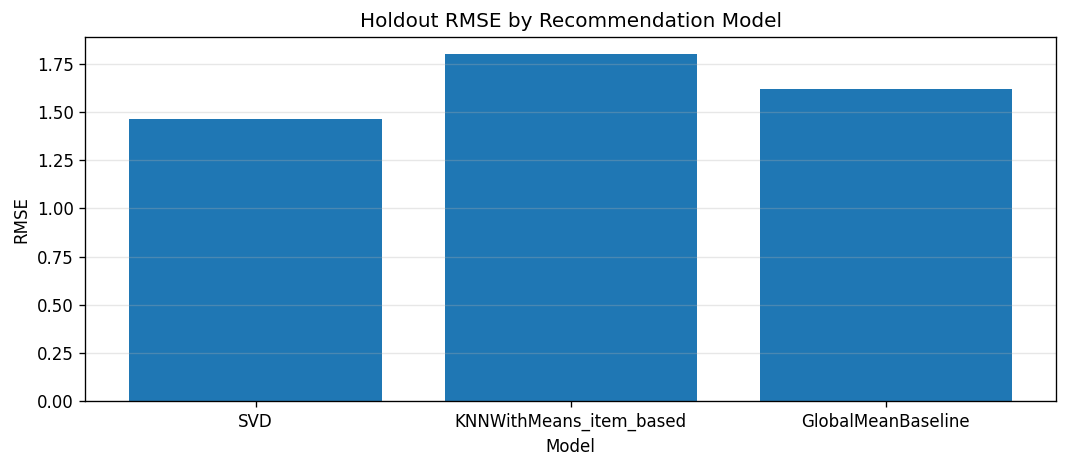

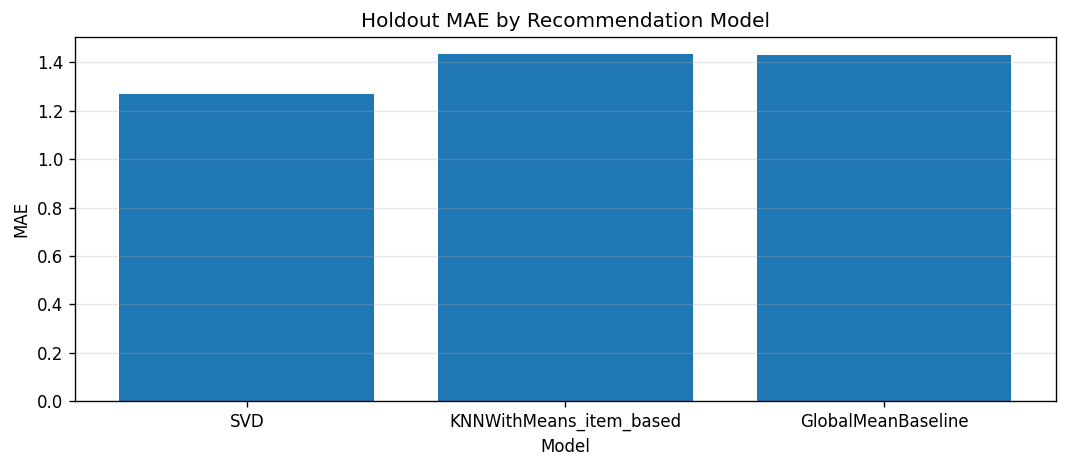

### Preliminary model selection note

,preliminary_best_model,selection_metric_primary,selection_metric_secondary,grid_search_pending
0,SVD,holdout_rmse,holdout_mae,True


Đã lưu: ..\artifacts\predictions\surprise_best_model_test_predictions.csv
Đã lưu: ..\artifacts\plots\surprise_holdout_rmse_comparison.png
Đã lưu: ..\artifacts\plots\surprise_holdout_mae_comparison.png


In [16]:
# =========================
# SELECT PRELIMINARY BEST MODEL
# =========================
best_model_name = str(holdout_metrics_df.iloc[0]["model"])
best_holdout_row = holdout_metrics_df.iloc[0].to_dict()

print("Preliminary best model:", best_model_name)
display(pd.DataFrame([best_holdout_row]))

best_test_predictions = holdout_prediction_registry[best_model_name].copy()
best_test_predictions_path = PRED_DIR / "surprise_best_model_test_predictions.csv"
best_test_predictions.to_csv(best_test_predictions_path, index=False)

comparison_plot_df = holdout_metrics_full_df.copy()

plt.figure(figsize=(9, 4))
plt.bar(comparison_plot_df["model"], comparison_plot_df["holdout_rmse"])
plt.title("Holdout RMSE by Recommendation Model")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
rmse_plot_path = PLOT_DIR / "surprise_holdout_rmse_comparison.png"
plt.savefig(rmse_plot_path, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(comparison_plot_df["model"], comparison_plot_df["holdout_mae"])
plt.title("Holdout MAE by Recommendation Model")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
mae_plot_path = PLOT_DIR / "surprise_holdout_mae_comparison.png"
plt.savefig(mae_plot_path, dpi=150, bbox_inches="tight")
plt.show()

selection_note_df = pd.DataFrame([{
    "preliminary_best_model": best_model_name,
    "selection_metric_primary": "holdout_rmse",
    "selection_metric_secondary": "holdout_mae",
    "grid_search_pending": bool(RUN_SURPRISE_GRID_SEARCH)
}])

display(Markdown("### Preliminary model selection note"))
display(selection_note_df)

print("Đã lưu:", best_test_predictions_path)
print("Đã lưu:", rmse_plot_path)
print("Đã lưu:", mae_plot_path)

## Cell 17: Đánh giá cross-validation

**Mục tiêu**
- Chạy `cross_validate` để tăng độ tin cậy của kết quả.
- Ghi lại mean/std cho `RMSE`, `MAE`.

**Lý do**
- Rubric phần Utilities đánh giá cao việc có **CV** và báo cáo kết quả rõ ràng.
- CV cũng giúp tránh dựa hoàn toàn vào một holdout split.

In [17]:
# =========================
# CROSS-VALIDATION
# - ưu tiên chạy cho tất cả model chính
# =========================
cv_rows = []

models_for_cv = list(holdout_metrics_df["model"].tolist()) if RUN_CV_ALL_MODELS else [best_model_name]

if RUN_CV_ALL_MODELS or RUN_CV_BEST_MODEL:
    for model_name in models_for_cv:
        print(f"Cross-validating: {model_name}")
        algo = model_factories[model_name]()

        cv_scores = cross_validate(
            algo,
            surprise_data,
            measures=["RMSE", "MAE"],
            cv=CV_FOLDS,
            verbose=False,
            n_jobs=1
        )

        cv_rows.append({
            "model": model_name,
            "cv_rmse_mean": float(np.mean(cv_scores["test_rmse"])),
            "cv_rmse_std": float(np.std(cv_scores["test_rmse"])),
            "cv_mae_mean": float(np.mean(cv_scores["test_mae"])),
            "cv_mae_std": float(np.std(cv_scores["test_mae"])),
            "fit_time_mean": float(np.mean(cv_scores["fit_time"])),
            "test_time_mean": float(np.mean(cv_scores["test_time"]))
        })

cv_metrics_df = pd.DataFrame(cv_rows)

if not cv_metrics_df.empty:
    cv_metrics_df = cv_metrics_df.sort_values(["cv_rmse_mean", "cv_mae_mean"], ascending=[True, True]).reset_index(drop=True)
    display(Markdown("### Cross-validation metrics"))
    display(cv_metrics_df)

cv_metrics_path = METRIC_DIR / "surprise_cv_metrics.csv"
cv_metrics_df.to_csv(cv_metrics_path, index=False)

print("Đã lưu:", cv_metrics_path)

Cross-validating: SVD
Cross-validating: KNNWithMeans_item_based


### Cross-validation metrics

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,fit_time_mean,test_time_mean
0,SVD,1.453679,0.048375,1.266226,0.037195,0.026964,0.002574
1,KNNWithMeans_item_based,1.832770,0.057089,1.473150,0.043794,0.017096,0.003034


Đã lưu: ..\artifacts\metrics\surprise_cv_metrics.csv


## Cell 18: Grid Search nhẹ cho SVD

**Mục tiêu**
- Tuning `SVD` trên một grid nhỏ nhưng thực sự chạy.
- Nếu `SVD_TUNED` tốt hơn, notebook sẽ cập nhật lại:
  - best model
  - holdout leaderboard
  - plots so sánh

**Lý do**
- Đây là phần giúp kéo điểm ở rubric **Utilities & Evaluation** và làm số liệu Recommendation mạnh hơn.

**Nguyên tắc sạch đánh giá**
- Grid search **chỉ được nhìn thấy train split**, không được fit trên toàn bộ `surprise_data`.
- Sau khi chọn `best_params`, notebook mới đánh giá `SVD_TUNED` trên **holdout testset** đang giữ riêng.
- Cách làm này giúp tránh leakage vào holdout và làm phần số liệu tuned dùng được an toàn hơn trong báo cáo.


### Tuning data summary

,tuning_source,train_rows_for_tuning,train_users_for_tuning,train_items_for_tuning,holdout_test_size
0,trainset_only,2150,1225,695,538


### Grid search SVD

,tuning_protocol,best_rmse_score,best_mae_score,best_params_rmse,best_params_mae,train_rows_for_tuning,train_users_for_tuning,train_items_for_tuning
0,grid_search_fit_on_train_split_only,1.457198,1.256746,"{""n_factors"": 50, ""n_epochs"": 40, ""lr_all"": 0....","{""n_factors"": 50, ""n_epochs"": 40, ""lr_all"": 0....",2150,1225,695


Đang đánh giá SVD_TUNED trên holdout split đang giữ riêng...


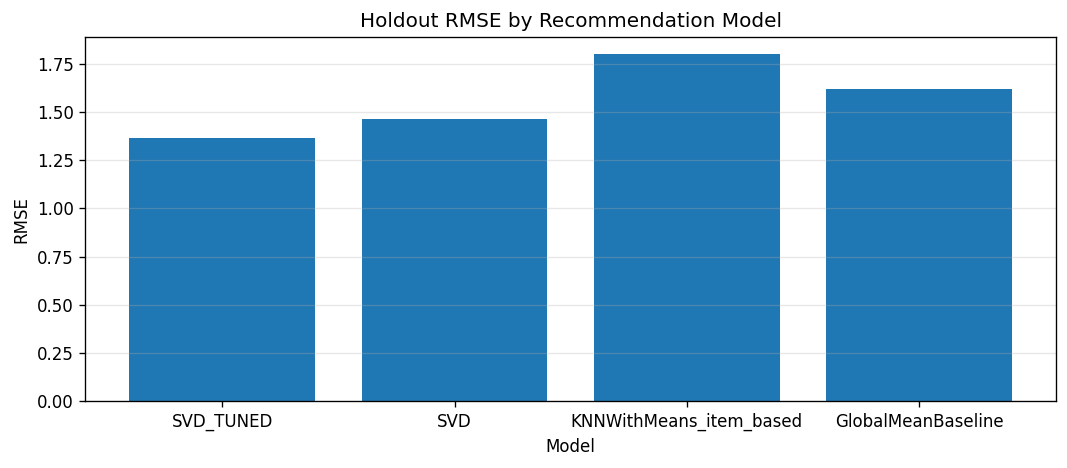

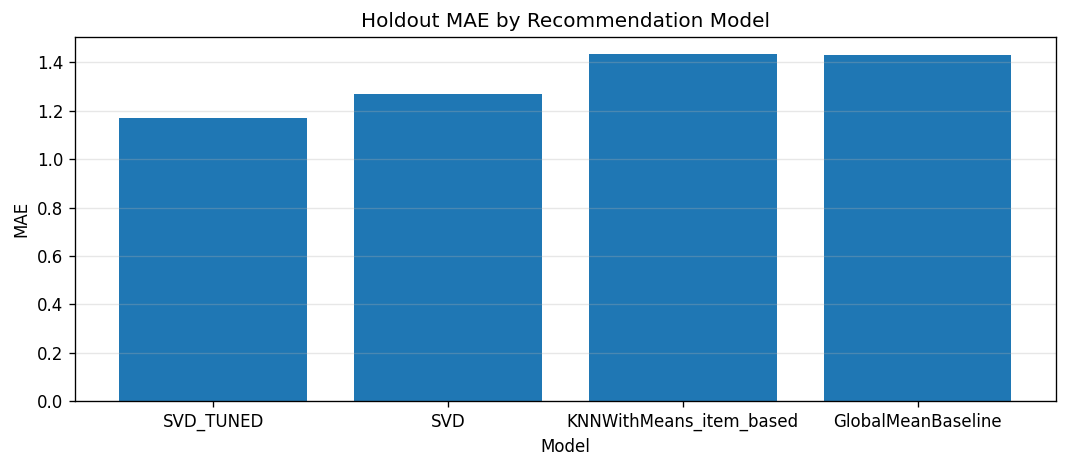

### Holdout metrics sau khi thêm SVD_TUNED

,model,holdout_rmse,holdout_mae,fit_time_sec,test_time_sec,n_test_predictions,selection_eligible
0,SVD_TUNED,1.366252,1.169300,0.022687,0.001361,538,True
1,SVD,1.461171,1.269002,0.043139,0.000000,538,True
2,KNNWithMeans_item_based,1.797616,1.432544,0.044266,0.004837,538,True


Best model after tuning step: SVD_TUNED
Đã lưu: ..\artifacts\metrics\surprise_svd_grid_search.csv


In [18]:
# =========================
# GRID SEARCH NHẸ CHO SVD
# - tuning sạch trên train split, không nhìn testset
# - nếu tuned SVD tốt hơn thì cập nhật lại best model
# =========================
svd_grid_results = pd.DataFrame()
train_df_for_tuning = pd.DataFrame()
surprise_train_for_tuning = None

if RUN_SURPRISE_GRID_SEARCH:
    # Rebuild training dataframe từ trainset hiện tại để grid search chỉ thấy train split.
    # Cách này giúp tránh leakage vào holdout testset.
    train_df_for_tuning = pd.DataFrame(
        [
            {
                "customer_unique_id": str(trainset.to_raw_uid(inner_uid)),
                "product_id": str(trainset.to_raw_iid(inner_iid)),
                "review_score": float(rating),
            }
            for inner_uid, inner_iid, rating in trainset.all_ratings()
        ]
    )

    surprise_train_for_tuning = Dataset.load_from_df(
        train_df_for_tuning[["customer_unique_id", "product_id", "review_score"]],
        reader
    )

    tuning_data_summary_df = pd.DataFrame([{
        "tuning_source": "trainset_only",
        "train_rows_for_tuning": int(len(train_df_for_tuning)),
        "train_users_for_tuning": int(train_df_for_tuning["customer_unique_id"].nunique()),
        "train_items_for_tuning": int(train_df_for_tuning["product_id"].nunique()),
        "holdout_test_size": int(len(testset))
    }])

    display(Markdown("### Tuning data summary"))
    display(tuning_data_summary_df)

    gs = SurpriseGridSearchCV(
        SVD,
        SVD_GRID_PARAM_GRID,
        measures=["rmse", "mae"],
        cv=min(3, CV_FOLDS),
        n_jobs=1,
        joblib_verbose=0
    )

    gs.fit(surprise_train_for_tuning)

    tuned_svd_params = deepcopy(gs.best_params["rmse"])
    tuned_svd_params["random_state"] = RANDOM_STATE
    model_factories = rebuild_model_factories()

    svd_grid_results = pd.DataFrame([{
        "tuning_protocol": "grid_search_fit_on_train_split_only",
        "best_rmse_score": float(gs.best_score["rmse"]),
        "best_mae_score": float(gs.best_score["mae"]),
        "best_params_rmse": json.dumps(gs.best_params["rmse"], ensure_ascii=False),
        "best_params_mae": json.dumps(gs.best_params["mae"], ensure_ascii=False),
        "train_rows_for_tuning": int(len(train_df_for_tuning)),
        "train_users_for_tuning": int(train_df_for_tuning["customer_unique_id"].nunique()),
        "train_items_for_tuning": int(train_df_for_tuning["product_id"].nunique())
    }])

    display(Markdown("### Grid search SVD"))
    display(svd_grid_results)

    print("Đang đánh giá SVD_TUNED trên holdout split đang giữ riêng...")
    tuned_algo = model_factories["SVD_TUNED"]()
    tuned_fitted_algo, tuned_result, tuned_pred_df = evaluate_surprise_model(
        "SVD_TUNED",
        tuned_algo,
        trainset,
        testset
    )

    holdout_prediction_registry["SVD_TUNED"] = tuned_pred_df
    trained_holdout_models["SVD_TUNED"] = tuned_fitted_algo

    holdout_metrics_df = pd.concat(
        [holdout_metrics_df, pd.DataFrame([tuned_result])],
        ignore_index=True
    ).sort_values(["holdout_rmse", "holdout_mae"], ascending=[True, True]).reset_index(drop=True)

    baseline_metrics_df = pd.DataFrame([baseline_holdout_row])
    holdout_metrics_full_df = pd.concat(
        [holdout_metrics_df, baseline_metrics_df],
        ignore_index=True
    ).sort_values(
        ["selection_eligible", "holdout_rmse", "holdout_mae"],
        ascending=[False, True, True]
    ).reset_index(drop=True)

    if RUN_CV_ALL_MODELS or RUN_CV_BEST_MODEL:
        tuned_cv_scores = cross_validate(
            model_factories["SVD_TUNED"](),
            surprise_data,
            measures=["RMSE", "MAE"],
            cv=CV_FOLDS,
            verbose=False,
            n_jobs=1
        )

        tuned_cv_row = pd.DataFrame([{
            "model": "SVD_TUNED",
            "cv_rmse_mean": float(np.mean(tuned_cv_scores["test_rmse"])),
            "cv_rmse_std": float(np.std(tuned_cv_scores["test_rmse"])),
            "cv_mae_mean": float(np.mean(tuned_cv_scores["test_mae"])),
            "cv_mae_std": float(np.std(tuned_cv_scores["test_mae"])),
            "fit_time_mean": float(np.mean(tuned_cv_scores["fit_time"])),
            "test_time_mean": float(np.mean(tuned_cv_scores["test_time"]))
        }])

        cv_metrics_df = pd.concat([cv_metrics_df, tuned_cv_row], ignore_index=True)
        cv_metrics_df = cv_metrics_df.sort_values(
            ["cv_rmse_mean", "cv_mae_mean"], ascending=[True, True]
        ).reset_index(drop=True)
        cv_metrics_df.to_csv(cv_metrics_path, index=False)

    best_model_name = str(holdout_metrics_df.iloc[0]["model"])
    best_holdout_row = holdout_metrics_df.iloc[0].to_dict()
    best_test_predictions = holdout_prediction_registry[best_model_name].copy()
    best_test_predictions.to_csv(best_test_predictions_path, index=False)

    holdout_metrics_df.to_csv(holdout_metrics_path, index=False)
    holdout_metrics_full_df.to_csv(holdout_metrics_extended_path, index=False)

    plt.figure(figsize=(9, 4))
    plt.bar(holdout_metrics_full_df["model"], holdout_metrics_full_df["holdout_rmse"])
    plt.title("Holdout RMSE by Recommendation Model")
    plt.xlabel("Model")
    plt.ylabel("RMSE")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(rmse_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.bar(holdout_metrics_full_df["model"], holdout_metrics_full_df["holdout_mae"])
    plt.title("Holdout MAE by Recommendation Model")
    plt.xlabel("Model")
    plt.ylabel("MAE")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(mae_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    display(Markdown("### Holdout metrics sau khi thêm SVD_TUNED"))
    display(holdout_metrics_df)

svd_grid_path = METRIC_DIR / "surprise_svd_grid_search.csv"
svd_grid_results.to_csv(svd_grid_path, index=False)

print("Best model after tuning step:", best_model_name)
print("Đã lưu:", svd_grid_path)


## Cell 19: Ranking evaluation và huấn luyện final model

**Mục tiêu**
1. Tính thêm ranking metrics cho best model:
   - `HitRate@10`
   - `Recall@10`
   - `MRR@10`
   - `NDCG@10`
   - `CatalogCoverage@10`
2. Sinh cảnh báo nếu chất lượng top-N còn yếu.
3. Train lại final model trên toàn bộ filtered data để chuẩn bị deployment.

**Giải thích nhanh các metric**
- `HitRate@10`: tỉ lệ user có ít nhất 1 item đúng xuất hiện trong top 10.
- `Recall@10`: top 10 thu hồi được bao nhiêu item relevant.
- `MRR@10`: item đúng có xuất hiện sớm trong danh sách hay không.
- `NDCG@10`: chất lượng thứ hạng tổng thể của top-N.
- `CatalogCoverage@10`: recommender có dùng được bao nhiêu item khác nhau trong catalog.

**Cách diễn giải đúng trong báo cáo**
- `RMSE/MAE` tốt hơn baseline **không đồng nghĩa** top-N đã mạnh.
- Nếu ranking metrics yếu, phải ghi rõ:
  - notebook đang mạnh hơn ở **rating prediction**
  - nhưng **top-N recommendation thực tế** còn bị giới hạn bởi sparsity, coverage thấp và việc dùng `review_score` làm proxy rating.


In [19]:
# =========================
# RANKING EVALUATION + RETRAIN BEST MODEL ON FULL FILTERED DATA
# =========================
candidate_item_ids_for_eval = sorted(surprise_df["product_id"].astype(str).unique().tolist())

def build_train_seen_map(trainset):
    train_seen_map = {}
    for inner_uid, interactions in trainset.ur.items():
        raw_uid = str(trainset.to_raw_uid(inner_uid))
        seen_items = set()
        for inner_iid, _ in interactions:
            seen_items.add(str(trainset.to_raw_iid(inner_iid)))
        train_seen_map[raw_uid] = seen_items
    return train_seen_map

def evaluate_topn_ranking_metrics(
    algo,
    trainset,
    testset,
    all_item_ids,
    top_n=10,
    positive_threshold=4
):
    relevant_by_user = defaultdict(set)
    for uid, iid, true_rating in testset:
        if float(true_rating) >= positive_threshold:
            relevant_by_user[str(uid)].add(str(iid))

    train_seen_map = build_train_seen_map(trainset)
    rows = []
    recommended_catalog = set()

    for uid, relevant_items in relevant_by_user.items():
        seen_items = train_seen_map.get(uid, set())
        candidate_items = [iid for iid in all_item_ids if iid not in seen_items]

        if len(candidate_items) == 0:
            continue

        scored = []
        for iid in candidate_items:
            try:
                est = float(algo.predict(uid, iid).est)
            except Exception:
                est = np.nan
            scored.append((iid, est))

        scored_df = pd.DataFrame(scored, columns=["product_id", "estimated_score"]).dropna()
        if scored_df.empty:
            continue

        top_df = (
            scored_df
            .sort_values(["estimated_score", "product_id"], ascending=[False, True])
            .drop_duplicates("product_id")
            .head(top_n)
            .copy()
        )

        top_items = top_df["product_id"].astype(str).tolist()
        recommended_catalog.update(top_items)

        hits = [iid for iid in top_items if iid in relevant_items]
        hit = int(len(hits) > 0)
        recall = len(hits) / len(relevant_items) if len(relevant_items) > 0 else np.nan

        reciprocal_rank = 0.0
        dcg = 0.0
        for rank, iid in enumerate(top_items, start=1):
            if iid in relevant_items:
                if reciprocal_rank == 0.0:
                    reciprocal_rank = 1.0 / rank
                dcg += 1.0 / np.log2(rank + 1)

        ideal_hits = min(len(relevant_items), top_n)
        idcg = sum(1.0 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))
        ndcg = dcg / idcg if idcg > 0 else np.nan

        rows.append({
            "customer_unique_id": uid,
            "n_relevant_test_items": int(len(relevant_items)),
            "n_recommended": int(len(top_items)),
            "hit_at_k": hit,
            "recall_at_k": float(recall) if pd.notna(recall) else np.nan,
            "mrr_at_k": float(reciprocal_rank),
            "ndcg_at_k": float(ndcg) if pd.notna(ndcg) else np.nan
        })

    user_level_df = pd.DataFrame(rows)

    if user_level_df.empty:
        summary_df = pd.DataFrame([{
            "model": best_model_name,
            "top_k": top_n,
            "positive_threshold": positive_threshold,
            "n_eval_users": 0,
            "hit_rate_at_k": np.nan,
            "mean_recall_at_k": np.nan,
            "mrr_at_k": np.nan,
            "ndcg_at_k": np.nan,
            "catalog_coverage_at_k": np.nan
        }])
        return user_level_df, summary_df

    summary_df = pd.DataFrame([{
        "model": best_model_name,
        "top_k": int(top_n),
        "positive_threshold": int(positive_threshold),
        "n_eval_users": int(len(user_level_df)),
        "hit_rate_at_k": float(user_level_df["hit_at_k"].mean()),
        "mean_recall_at_k": float(user_level_df["recall_at_k"].mean()),
        "mrr_at_k": float(user_level_df["mrr_at_k"].mean()),
        "ndcg_at_k": float(user_level_df["ndcg_at_k"].mean()),
        "catalog_coverage_at_k": float(len(recommended_catalog) / len(all_item_ids)) if len(all_item_ids) > 0 else np.nan
    }])

    return user_level_df, summary_df

ranking_user_metrics_df = pd.DataFrame()
ranking_summary_df = pd.DataFrame()
ranking_diagnosis_df = pd.DataFrame()
ranking_warning = ""
ranking_user_metrics_path = METRIC_DIR / "surprise_ranking_user_level.csv"
ranking_summary_path = METRIC_DIR / "surprise_ranking_metrics.csv"

if RUN_RANKING_EVAL:
    ranking_user_metrics_df, ranking_summary_df = evaluate_topn_ranking_metrics(
        algo=trained_holdout_models[best_model_name],
        trainset=trainset,
        testset=testset,
        all_item_ids=candidate_item_ids_for_eval,
        top_n=TOP_N,
        positive_threshold=POSITIVE_RATING_THRESHOLD
    )

    if not ranking_summary_df.empty:
        row = ranking_summary_df.iloc[0]
        ranking_status = "acceptable"
        if (
            float(row["hit_rate_at_k"]) < RANKING_HITRATE_WARN_THRESHOLD
            or float(row["ndcg_at_k"]) < RANKING_NDCG_WARN_THRESHOLD
        ):
            ranking_status = "weak"
            ranking_warning = (
                f"Ranking yếu: HitRate@{int(row['top_k'])}={row['hit_rate_at_k']:.4f}, "
                f"Recall@{int(row['top_k'])}={row['mean_recall_at_k']:.4f}, "
                f"MRR@{int(row['top_k'])}={row['mrr_at_k']:.4f}, "
                f"NDCG@{int(row['top_k'])}={row['ndcg_at_k']:.4f}. "
                "Kết quả top-N chỉ phù hợp mức demo/đồ án, chưa mạnh ở mức production."
            )
        else:
            ranking_warning = (
                f"Ranking chấp nhận được: HitRate@{int(row['top_k'])}={row['hit_rate_at_k']:.4f}, "
                f"NDCG@{int(row['top_k'])}={row['ndcg_at_k']:.4f}."
            )

        ranking_diagnosis_df = pd.DataFrame([{
            "ranking_status": ranking_status,
            "hit_rate_at_k": float(row["hit_rate_at_k"]),
            "mean_recall_at_k": float(row["mean_recall_at_k"]),
            "mrr_at_k": float(row["mrr_at_k"]),
            "ndcg_at_k": float(row["ndcg_at_k"]),
            "catalog_coverage_at_k": float(row["catalog_coverage_at_k"]),
            "warning": ranking_warning
        }])

    display(Markdown("### Ranking metrics - summary"))
    display(ranking_summary_df)

    display(Markdown("### Ranking metrics - diagnosis"))
    display(ranking_diagnosis_df if len(ranking_diagnosis_df) > 0 else pd.DataFrame({"message": ["Chưa có diagnosis"]}))

    display(Markdown("### Ranking metrics - user level sample"))
    display(ranking_user_metrics_df.head(10))

ranking_user_metrics_df.to_csv(ranking_user_metrics_path, index=False)
ranking_summary_df.to_csv(ranking_summary_path, index=False)

full_data = Dataset.load_from_df(
    surprise_df[["customer_unique_id", "product_id", "review_score"]],
    reader
)
full_trainset = full_data.build_full_trainset()

best_algo_full = model_factories[best_model_name]()
best_algo_full.fit(full_trainset)

final_model_params = get_model_params_by_name(best_model_name)

if best_model_name == "SVD_TUNED":
    final_model_selection_reason = "SVD_TUNED tốt nhất theo holdout sau grid search fit trên train split và đã có CV."
elif best_model_name == "SVD":
    final_model_selection_reason = "SVD tốt nhất theo holdout; tuning không vượt qua baseline model selection."
else:
    final_model_selection_reason = "KNNWithMeans item-based tốt nhất theo holdout trên filtered data."

display(Markdown("### Final model retrained on full filtered data"))
display(pd.DataFrame([{
    "best_model_name": best_model_name,
    "full_trainset_users": int(full_trainset.n_users),
    "full_trainset_items": int(full_trainset.n_items),
    "full_trainset_ratings": int(full_trainset.n_ratings),
    "final_model_params": json.dumps(final_model_params, ensure_ascii=False),
    "final_model_selection_reason": final_model_selection_reason,
    "ranking_warning": ranking_warning if ranking_warning else "Không có cảnh báo ranking"
}]))

print("Đã lưu:", ranking_user_metrics_path)
print("Đã lưu:", ranking_summary_path)


### Ranking metrics - summary

,model,top_k,positive_threshold,n_eval_users,hit_rate_at_k,mean_recall_at_k,mrr_at_k,ndcg_at_k,catalog_coverage_at_k
0,SVD_TUNED,10,4,308,0.038961,0.037338,0.010415,0.016282,0.145863


### Ranking metrics - diagnosis

,ranking_status,hit_rate_at_k,mean_recall_at_k,mrr_at_k,ndcg_at_k,catalog_coverage_at_k,warning
0,weak,0.038961,0.037338,0.010415,0.016282,0.145863,"Ranking yếu: HitRate@10=0.0390, Recall@10=0.03..."


### Ranking metrics - user level sample

,customer_unique_id,n_relevant_test_items,n_recommended,hit_at_k,recall_at_k,mrr_at_k,ndcg_at_k
0,731ea3afd190908a9cbed04f42aa51e2,2,10,0,0.0,0.0,0.0
1,5ebc16fa8e8f7628425904c85c99760a,1,10,0,0.0,0.0,0.0
2,5e0aa142dc4760e62a74c1830cbf91b1,1,10,0,0.0,0.0,0.0
3,54eb010282ed1c4a38e101aa8b9aca37,1,10,0,0.0,0.0,0.0
4,354004e1432bff6f9008ce0a5afd732a,1,10,0,0.0,0.0,0.0
5,fd756efade2d13c0c94d1dd1eeb2169f,1,10,0,0.0,0.0,0.0
6,bd7d88dec7e9cce42ae70631cd7b25ee,1,10,0,0.0,0.0,0.0
7,b9fc2d4c90bdadc7052fabe8353084ed,1,10,0,0.0,0.0,0.0
8,88d083c794a4e721f296f8423e68821f,1,10,0,0.0,0.0,0.0
9,5b3619dbe8789d4d059f8e5725d77a13,2,10,0,0.0,0.0,0.0


### Final model retrained on full filtered data

,best_model_name,full_trainset_users,full_trainset_items,full_trainset_ratings,final_model_params,final_model_selection_reason,ranking_warning
0,SVD_TUNED,1272,713,2688,"{""n_factors"": 50, ""n_epochs"": 40, ""lr_all"": 0....",SVD_TUNED tốt nhất theo holdout sau grid searc...,"Ranking yếu: HitRate@10=0.0390, Recall@10=0.03..."


Đã lưu: ..\artifacts\metrics\surprise_ranking_user_level.csv
Đã lưu: ..\artifacts\metrics\surprise_ranking_metrics.csv


## Cell 20: Xây dựng asset cho deployment

**Mục tiêu**
- Chuẩn bị các asset cần cho UI/integration:
  - `known_users`
  - `known_items`
  - `candidate_items`
  - `seen_items_map`

**Lý do**
- Những file này giúp trang Recommendation trong Streamlit hoạt động mà không phải đọc lại toàn bộ notebook.

In [20]:
# =========================
# BUILD DEPLOYMENT ASSETS
# =========================
# seen_items_map dùng ratings_full để tránh recommend lại item mà user từng thấy,
# kể cả item đó không còn nằm trong filtered candidate catalog.
seen_items_map = (
    ratings_full.groupby("customer_unique_id")["product_id"]
    .apply(lambda x: set(x.dropna().astype(str)))
    .to_dict()
)

candidate_item_ids = sorted(surprise_df["product_id"].astype(str).unique().tolist())
known_users_set = set(surprise_df["customer_unique_id"].astype(str).unique())
known_items_set = set(candidate_item_ids)

known_users_df = pd.DataFrame({"customer_unique_id": sorted(known_users_set)})
known_items_df = pd.DataFrame({"product_id": sorted(known_items_set)})
candidate_items_df = pd.DataFrame({"product_id": candidate_item_ids})

known_users_path = DATA_ARTIFACT_DIR / "known_users.csv"
known_items_path = DATA_ARTIFACT_DIR / "known_items.csv"
candidate_items_path = DATA_ARTIFACT_DIR / "candidate_items.csv"

known_users_df.to_csv(known_users_path, index=False)
known_items_df.to_csv(known_items_path, index=False)
candidate_items_df.to_csv(candidate_items_path, index=False)

deployment_asset_summary_df = pd.DataFrame([{
    "known_users": int(len(known_users_df)),
    "known_items": int(len(known_items_df)),
    "candidate_items": int(len(candidate_items_df)),
    "seen_items_map_users": int(len(seen_items_map))
}])

display(Markdown("### Deployment asset summary"))
display(deployment_asset_summary_df)

print("Đã lưu:", known_users_path)
print("Đã lưu:", known_items_path)
print("Đã lưu:", candidate_items_path)

### Deployment asset summary

,known_users,known_items,candidate_items,seen_items_map_users
0,1272,713,713,94721


Đã lưu: ..\artifacts\data\known_users.csv
Đã lưu: ..\artifacts\data\known_items.csv
Đã lưu: ..\artifacts\data\candidate_items.csv


## Cell 21: Định nghĩa các hàm hỗ trợ recommendation

**Mục tiêu**
- Viết helper function ổn định cho:
  - enrich metadata
  - popularity fallback
  - top-up fallback
  - top-N recommendation cho known user / unknown user

**Yêu cầu kỹ thuật**
- Không để merge sinh `_x`, `_y`
- Không recommend lại item user đã thấy
- Nếu model không trả đủ `TOP_N`, phải tự top-up bằng fallback

In [21]:
# =========================
# RECOMMENDATION HELPERS
# =========================
LOOKUP_META_COLS = [
    "product_category_name_english",
    "avg_price",
    "purchase_count",
    "rating_mean",
    "rating_count",
    "weighted_rating"
]

def coalesce_lookup_columns(df):
    if df is None or len(df) == 0:
        return df

    out = df.copy()

    for col in LOOKUP_META_COLS:
        x_col = f"{col}_x"
        y_col = f"{col}_y"

        if col not in out.columns:
            if x_col in out.columns and y_col in out.columns:
                out[col] = out[x_col].combine_first(out[y_col])
            elif x_col in out.columns:
                out[col] = out[x_col]
            elif y_col in out.columns:
                out[col] = out[y_col]

        drop_cols = [c for c in [x_col, y_col] if c in out.columns]
        if drop_cols:
            out = out.drop(columns=drop_cols)

    if "product_id" in out.columns:
        out["product_id"] = out["product_id"].astype(str).str.strip()

    if "product_category_name_english" in out.columns:
        out["product_category_name_english"] = (
            out["product_category_name_english"]
            .fillna("unknown")
            .astype(str)
            .str.strip()
            .replace("", "unknown")
        )

    return out

def enrich_with_product_lookup(df, product_lookup_df):
    if df is None or len(df) == 0:
        return df

    out = coalesce_lookup_columns(df)

    if any(col in out.columns for col in LOOKUP_META_COLS):
        return out

    if product_lookup_df is None or len(product_lookup_df) == 0:
        return out

    lookup = product_lookup_df.copy()

    if "product_id" not in lookup.columns:
        return out

    lookup["product_id"] = lookup["product_id"].astype(str).str.strip()
    lookup = lookup.dropna(subset=["product_id"]).drop_duplicates("product_id")

    preferred_lookup_cols = ["product_id"] + [c for c in LOOKUP_META_COLS if c in lookup.columns]
    lookup = lookup[preferred_lookup_cols].copy()

    if "product_id" in out.columns:
        out["product_id"] = out["product_id"].astype(str).str.strip()

    enriched = out.merge(lookup, on="product_id", how="left")
    return coalesce_lookup_columns(enriched)

def build_fallback_output(fallback_df, n=10, reason="cold_start_popularity", exclude_product_ids=None):
    if fallback_df is None or len(fallback_df) == 0:
        return pd.DataFrame(columns=["product_id", "estimated_score", "reason", "recommendation_rank"])

    exclude_ids = {str(x).strip() for x in (exclude_product_ids or [])}
    out = fallback_df.copy()

    if "product_id" in out.columns:
        out["product_id"] = out["product_id"].astype(str).str.strip()
        if exclude_ids:
            out = out[~out["product_id"].isin(exclude_ids)].copy()

    out = out.drop_duplicates("product_id").head(n).copy()
    out["estimated_score"] = pd.to_numeric(out.get("weighted_rating", np.nan), errors="coerce")
    out["estimated_score"] = out["estimated_score"].clip(RATING_SCALE[0], RATING_SCALE[1])
    out["reason"] = reason
    out["recommendation_rank"] = range(1, len(out) + 1)

    return coalesce_lookup_columns(out)

def append_fallback_rows(reco_df, fallback_df, n=10, exclude_product_ids=None, reason="topup_popularity_fallback"):
    if reco_df is None or len(reco_df) == 0:
        return build_fallback_output(
            fallback_df=fallback_df,
            n=n,
            reason=reason,
            exclude_product_ids=exclude_product_ids
        )

    out = reco_df.copy()
    exclude_ids = {str(x).strip() for x in (exclude_product_ids or [])}

    if "product_id" in out.columns:
        exclude_ids.update(out["product_id"].astype(str).str.strip().tolist())

    needed = max(0, n - len(out))
    if needed > 0:
        extra_df = build_fallback_output(
            fallback_df=fallback_df,
            n=needed,
            reason=reason,
            exclude_product_ids=exclude_ids
        )
        out = pd.concat([out, extra_df], ignore_index=True)

    if "product_id" in out.columns:
        out["product_id"] = out["product_id"].astype(str).str.strip()
        out = out.drop_duplicates("product_id", keep="first")

    out = out.head(n).copy()
    out["recommendation_rank"] = range(1, len(out) + 1)

    return coalesce_lookup_columns(out)

def get_popular_fallback(n=10, exclude_product_ids=None, reason="cold_start_popularity"):
    return build_fallback_output(
        fallback_df=popularity_fallback,
        n=n,
        reason=reason,
        exclude_product_ids=exclude_product_ids
    )

def recommend_top_n_for_user(
    raw_uid,
    algo,
    all_item_ids,
    seen_map,
    product_lookup_df,
    fallback_df,
    known_users,
    n=10
):
    raw_uid = str(raw_uid)

    if raw_uid not in known_users:
        return get_popular_fallback(
            n=n,
            reason="cold_start_popularity"
        )

    seen_items = {str(i).strip() for i in seen_map.get(raw_uid, set())}
    candidates = [str(iid) for iid in all_item_ids if str(iid) not in seen_items]

    if len(candidates) == 0:
        return get_popular_fallback(
            n=n,
            exclude_product_ids=seen_items,
            reason="no_unseen_items_fallback"
        )

    scored = []
    for iid in candidates:
        try:
            est = float(algo.predict(raw_uid, iid).est)
        except Exception:
            est = np.nan
        scored.append((iid, est))

    reco_df = pd.DataFrame(scored, columns=["product_id", "estimated_score"])
    reco_df = reco_df.dropna(subset=["estimated_score"]).copy()

    if reco_df.empty:
        return get_popular_fallback(
            n=n,
            exclude_product_ids=seen_items,
            reason="prediction_failed_fallback"
        )

    reco_df["estimated_score"] = reco_df["estimated_score"].clip(RATING_SCALE[0], RATING_SCALE[1])

    reco_df = (
        reco_df
        .sort_values(["estimated_score", "product_id"], ascending=[False, True])
        .drop_duplicates("product_id")
        .head(n)
        .copy()
    )
    reco_df["reason"] = "collaborative_filtering"
    reco_df["recommendation_rank"] = range(1, len(reco_df) + 1)

    reco_df = enrich_with_product_lookup(reco_df, product_lookup_df)
    reco_df = append_fallback_rows(
        reco_df=reco_df,
        fallback_df=fallback_df,
        n=n,
        exclude_product_ids=seen_items,
        reason="topup_popularity_fallback"
    )

    return coalesce_lookup_columns(reco_df)

## Cell 22: Sinh recommendation mẫu

**Mục tiêu**
- Tạo ví dụ top-N cho:
  - một số known user
  - một user cold-start

**Lý do**
- Đây là bằng chứng trực quan cho báo cáo và demo UI.
- Output cần đủ metadata để screenshot / giải thích dễ.

In [22]:
# =========================
# SAMPLE RECOMMENDATIONS
# =========================
sample_known_user_df = (
    ratings_model_df.groupby("customer_unique_id")["product_id"]
    .size()
    .reset_index(name="rating_count")
    .sort_values(["rating_count", "customer_unique_id"], ascending=[False, True])
    .head(3)
    .copy()
)

sample_known_users = sample_known_user_df["customer_unique_id"].tolist()
sample_users = sample_known_users + ["cold_start_demo_user"]

display(Markdown("### Sample user selection"))
display(sample_known_user_df)

sample_recommendations = []
for uid in sample_users:
    recs = recommend_top_n_for_user(
        raw_uid=uid,
        algo=best_algo_full,
        all_item_ids=candidate_item_ids,
        seen_map=seen_items_map,
        product_lookup_df=product_lookup,
        fallback_df=popularity_fallback,
        known_users=known_users_set,
        n=TOP_N
    )
    recs = recs.copy()
    recs.insert(0, "customer_unique_id", uid)
    sample_recommendations.append(recs)

sample_recommendations_df = pd.concat(sample_recommendations, ignore_index=True)

numeric_cols_to_round = ["estimated_score", "avg_price", "rating_mean", "weighted_rating"]
for col in numeric_cols_to_round:
    if col in sample_recommendations_df.columns:
        sample_recommendations_df[col] = pd.to_numeric(sample_recommendations_df[col], errors="coerce").round(4)

sample_recommendations_path = PRED_DIR / "sample_recommendations.csv"
sample_recommendations_df.to_csv(sample_recommendations_path, index=False)

display(Markdown("### Sample recommendations"))
display(sample_recommendations_df.head(30))

print("Đã lưu:", sample_recommendations_path)

### Sample user selection

,customer_unique_id,rating_count
847,acea6bd29b8c1e3c6a8b266a8fb4475e,6
886,b2bd387fdc3cf05931f0f897d607dc88,5
135,1dfbdc636de09adbcdbc3d34e15084f3,4


### Sample recommendations

,customer_unique_id,product_id,estimated_score,reason,recommendation_rank,product_category_name_english,avg_price,purchase_count,rating_mean,rating_count,weighted_rating
0,acea6bd29b8c1e3c6a8b266a8fb4475e,b623b7cb05ee3248fbe4a6ecbeed79a4,3.9014,collaborative_filtering,1,toys,73.1292,66,4.0357,56,NaN
1,acea6bd29b8c1e3c6a8b266a8fb4475e,1427b126f61597524866770b05d4eed2,3.7912,collaborative_filtering,2,computers_accessories,98.0000,14,4.4286,14,NaN
2,acea6bd29b8c1e3c6a8b266a8fb4475e,16241e79b047426033194065d8b321b2,3.7649,collaborative_filtering,3,furniture_decor,31.1950,8,4.2500,8,NaN
3,acea6bd29b8c1e3c6a8b266a8fb4475e,dd6a505f83dd3c6326aa9856519e0978,3.7538,collaborative_filtering,4,toys,49.7914,36,4.6944,36,NaN
4,acea6bd29b8c1e3c6a8b266a8fb4475e,a6ad77b15e566298a4e8ee2011ab1255,3.7407,collaborative_filtering,5,furniture_decor,29.6400,40,4.2105,19,NaN
5,acea6bd29b8c1e3c6a8b266a8fb4475e,82a61259a621866c4ba63743da29a342,3.7325,collaborative_filtering,6,sports_leisure,124.2188,16,4.7333,15,NaN
6,acea6bd29b8c1e3c6a8b266a8fb4475e,fbc1488c1a1e72ba175f53ab29a248e8,3.7258,collaborative_filtering,7,perfumery,118.4912,58,4.6364,55,NaN
7,acea6bd29b8c1e3c6a8b266a8fb4475e,c211ff3068fcd2f8898192976d8b3a32,3.7014,collaborative_filtering,8,bed_bath_table,24.9000,38,4.2903,31,NaN
8,acea6bd29b8c1e3c6a8b266a8fb4475e,4630761de87581e8b659dc77bb7eb4ee,3.6989,collaborative_filtering,9,luggage_accessories,72.7400,2,5.0000,2,NaN
9,acea6bd29b8c1e3c6a8b266a8fb4475e,014a8a503291921f7b004a5215bb3c36,3.6917,collaborative_filtering,10,baby,36.5967,18,4.1111,18,NaN


Đã lưu: ..\artifacts\predictions\sample_recommendations.csv


## Cell 23: Xây dựng gợi ý sản phẩm tương tự theo `product_id`

**Mục tiêu**
- Hỗ trợ thêm flow UI khi người dùng nhập `product_id` thay vì `customer_unique_id`.

**Nguyên tắc kỹ thuật của cell này**
- Đây là **tính năng phụ**, không thay vai trò của module recommendation chính.
- Chỉ giữ lại neighbor có `similarity > 0` để tránh xuất các “neighbor giả”.
- Nếu neighbor thật không đủ, notebook sẽ **top-up bằng fallback phổ biến** nhưng vẫn gắn `reason` rõ ràng.

**Cách ghi đúng trong báo cáo**
- `product_id neighbors` là tính năng phụ phục vụ demo/UI.
- Không được mô tả phần này như bằng chứng chính cho chất lượng recommendation nếu similarity thấp hoặc phải fallback nhiều.


In [23]:
# =========================
# OPTIONAL: PRODUCT NEIGHBORS FOR INPUT product_id
# - giữ như tính năng phụ cho UI
# =========================
item_knn_model = None
sample_neighbors_df = pd.DataFrame()
neighbor_quality_df = pd.DataFrame()
neighbor_quality_path = METRIC_DIR / "surprise_neighbor_quality.csv"

def build_neighbor_fallback(fallback_df, query_product_id, n=10, reason="unknown_item_fallback"):
    out = fallback_df.copy()

    if "product_id" in out.columns:
        out["product_id"] = out["product_id"].astype(str).str.strip()
        out = out[out["product_id"] != str(query_product_id)].copy()

    out = out.drop_duplicates("product_id").head(n).copy()
    out["neighbor_rank"] = range(1, len(out) + 1)
    out["similarity"] = np.nan
    out["reason"] = reason

    return coalesce_lookup_columns(out)

def recommend_similar_products(product_id, knn_algo, product_lookup_df, fallback_df, n=10):
    product_id = str(product_id)

    if knn_algo is None or not hasattr(knn_algo, "trainset"):
        return build_neighbor_fallback(
            fallback_df=fallback_df,
            query_product_id=product_id,
            n=n,
            reason="item_knn_unavailable_fallback"
        )

    try:
        inner_iid = knn_algo.trainset.to_inner_iid(product_id)
        neighbor_inner_ids = knn_algo.get_neighbors(inner_iid, k=n + 20)

        pairs = []
        seen_raw_ids = set()

        for ni in neighbor_inner_ids:
            raw_iid = str(knn_algo.trainset.to_raw_iid(ni))
            if raw_iid == product_id or raw_iid in seen_raw_ids:
                continue

            sim_val = np.nan
            if hasattr(knn_algo, "sim"):
                try:
                    other_inner_iid = knn_algo.trainset.to_inner_iid(raw_iid)
                    sim_val = float(knn_algo.sim[inner_iid, other_inner_iid])
                except Exception:
                    sim_val = np.nan

            if pd.notna(sim_val) and sim_val > MIN_NEIGHBOR_SIMILARITY:
                pairs.append((raw_iid, sim_val))
                seen_raw_ids.add(raw_iid)

            if len(pairs) >= n:
                break

        out = pd.DataFrame(pairs, columns=["product_id", "similarity"])

        if len(out) < n:
            used_ids = set(out["product_id"].astype(str).tolist()) | {product_id}
            fallback_extra = build_neighbor_fallback(
                fallback_df=fallback_df,
                query_product_id=product_id,
                n=n,
                reason="fallback_completion"
            )
            if "product_id" in fallback_extra.columns:
                fallback_extra = fallback_extra[
                    ~fallback_extra["product_id"].astype(str).isin(used_ids)
                ].copy()
            fallback_extra = fallback_extra.head(n - len(out)).copy()
            if len(fallback_extra) > 0:
                out = pd.concat(
                    [out, fallback_extra[["product_id", "similarity"]]],
                    ignore_index=True
                )

        if out.empty:
            return build_neighbor_fallback(
                fallback_df=fallback_df,
                query_product_id=product_id,
                n=n,
                reason="unknown_item_fallback"
            )

        out = out.drop_duplicates("product_id").head(n).copy()
        out["neighbor_rank"] = range(1, len(out) + 1)
        out["reason"] = np.where(
            out["similarity"].notna(),
            "item_knn_neighbors",
            "fallback_completion"
        )

        out = enrich_with_product_lookup(out, product_lookup_df)
        out = coalesce_lookup_columns(out)

        return out

    except ValueError:
        return build_neighbor_fallback(
            fallback_df=fallback_df,
            query_product_id=product_id,
            n=n,
            reason="unknown_item_fallback"
        )

if RUN_PRODUCT_NEIGHBORS:
    print("Đang chuẩn bị item-based KNN để hỗ trợ product neighbors...")

    if best_model_name == "KNNWithMeans_item_based":
        item_knn_model = best_algo_full
    else:
        item_knn_model = KNNWithMeans(**selected_knn_params)
        item_knn_model.fit(full_trainset)

    sample_items = (
        popularity_fallback["product_id"]
        .astype(str)
        .loc[lambda s: s.isin(known_items_set)]
        .head(2)
        .tolist()
    )

    if len(sample_items) < 2:
        extra_items = (
            pd.Series(candidate_item_ids, dtype=str)
            .loc[lambda s: ~s.isin(sample_items)]
            .head(2 - len(sample_items))
            .tolist()
        )
        sample_items.extend(extra_items)

    sample_items = sample_items + ["cold_start_demo_product"]

    neighbor_frames = []
    for pid in sample_items:
        one_neighbors = recommend_similar_products(
            product_id=pid,
            knn_algo=item_knn_model,
            product_lookup_df=product_lookup,
            fallback_df=popularity_fallback,
            n=TOP_N
        )
        one_neighbors = one_neighbors.copy()
        one_neighbors.insert(0, "query_product_id", pid)
        neighbor_frames.append(one_neighbors)

    sample_neighbors_df = pd.concat(neighbor_frames, ignore_index=True)
    sample_neighbors_df = coalesce_lookup_columns(sample_neighbors_df)

numeric_cols_to_round = ["similarity", "avg_price", "rating_mean", "weighted_rating"]
for col in numeric_cols_to_round:
    if col in sample_neighbors_df.columns:
        sample_neighbors_df[col] = pd.to_numeric(sample_neighbors_df[col], errors="coerce").round(4)

sample_neighbors_path = PRED_DIR / "sample_product_neighbors.csv"
sample_neighbors_df.to_csv(sample_neighbors_path, index=False)

if not sample_neighbors_df.empty:
    neighbor_quality_df = (
        sample_neighbors_df.groupby("query_product_id", as_index=False)
        .agg(
            n_rows=("product_id", "size"),
            n_real_neighbors=("similarity", lambda x: int(pd.Series(x).notna().sum())),
            max_similarity=("similarity", "max"),
            mean_similarity=("similarity", "mean")
        )
    )

    neighbor_quality_df["neighbor_status"] = np.where(
        neighbor_quality_df["n_real_neighbors"] > 0,
        "has_real_neighbors",
        "fallback_only"
    )

neighbor_quality_df.to_csv(neighbor_quality_path, index=False)

if not sample_neighbors_df.empty:
    display(Markdown("### Sample product neighbors"))
    display(sample_neighbors_df.head(30))

display(Markdown("### Neighbor quality summary"))
display(neighbor_quality_df if len(neighbor_quality_df) > 0 else pd.DataFrame({"message": ["Chưa có neighbor quality data"]}))

print("Đã lưu:", sample_neighbors_path)
print("Đã lưu:", neighbor_quality_path)


Đang chuẩn bị item-based KNN để hỗ trợ product neighbors...


### Sample product neighbors

,query_product_id,product_id,similarity,neighbor_rank,reason,product_category_name_english,avg_price,purchase_count,rating_mean,rating_count,weighted_rating
0,73326828aa5efe1ba096223de496f596,f731f8587d4088c174397e010cf892a9,1.0,1,item_knn_neighbors,perfumery,56.8537,30,4.3448,29,NaN
1,73326828aa5efe1ba096223de496f596,12087840651e83b48206b82c213b76fd,1.0,2,item_knn_neighbors,sports_leisure,207.8889,9,4.6667,9,NaN
2,73326828aa5efe1ba096223de496f596,3e4176d545618ed02f382a3057de32b4,NaN,3,fallback_completion,luggage_accessories,132.3796,24,4.9583,24,NaN
3,73326828aa5efe1ba096223de496f596,6a8631b72a2f8729b91514db87e771c0,NaN,4,fallback_completion,electronics,26.6419,62,4.7368,57,NaN
4,73326828aa5efe1ba096223de496f596,f7f59e6186e10983a061ac7bdb3494d6,NaN,5,fallback_completion,housewares,34.9000,39,4.8148,27,NaN
5,73326828aa5efe1ba096223de496f596,62c89abe1afe3a23c17765d462718a4c,NaN,6,fallback_completion,perfumery,244.8125,16,4.9375,16,NaN
6,73326828aa5efe1ba096223de496f596,574597aaf385996112490308e37399ce,NaN,7,fallback_completion,housewares,49.0000,24,4.8261,23,NaN
7,73326828aa5efe1ba096223de496f596,2722b7e5f68e776d18fe901638034e54,NaN,8,fallback_completion,health_beauty,28.6692,13,5.0000,13,NaN
8,73326828aa5efe1ba096223de496f596,e7f85e7f0203b7b95cc1b4c21b4b070c,NaN,9,fallback_completion,cool_stuff,263.9074,23,4.8500,20,NaN
9,73326828aa5efe1ba096223de496f596,475e8a9ddbebf13af503d1c7eccadb1a,NaN,10,fallback_completion,office_furniture,136.1632,19,4.8824,17,NaN


### Neighbor quality summary

,query_product_id,n_rows,n_real_neighbors,max_similarity,mean_similarity,neighbor_status
0,73326828aa5efe1ba096223de496f596,10,2,1.0,1.0,has_real_neighbors
1,cold_start_demo_product,10,0,NaN,NaN,fallback_only
2,dd6a505f83dd3c6326aa9856519e0978,10,5,1.0,1.0,has_real_neighbors


Đã lưu: ..\artifacts\predictions\sample_product_neighbors.csv
Đã lưu: ..\artifacts\metrics\surprise_neighbor_quality.csv


## Cell 24: Lưu mô hình và deployment bundle

**Mục tiêu**
- Lưu final model và các object cần cho integration:
  - best Surprise model
  - `seen_items_map`
  - optional `item_knn_neighbors_model`
  - deployment bundle

**Ràng buộc tương thích**
- Giữ nguyên tên file output chính để không làm gãy notebook 08 và phần UI.

In [24]:
# =========================
# SAVE MODELS & DEPLOYMENT BUNDLES
# =========================
best_model_path = MODEL_DIR / "best_surprise_model.pkl"
with open(best_model_path, "wb") as f:
    pickle.dump(best_algo_full, f)

seen_map_path = MODEL_DIR / "seen_items_map.pkl"
with open(seen_map_path, "wb") as f:
    pickle.dump(seen_items_map, f)

if RUN_PRODUCT_NEIGHBORS and item_knn_model is not None:
    item_knn_model_path = MODEL_DIR / "item_knn_neighbors_model.pkl"
    with open(item_knn_model_path, "wb") as f:
        pickle.dump(item_knn_model, f)
else:
    item_knn_model_path = None

deployment_bundle = {
    "model_name": best_model_name,
    "top_n_default": int(TOP_N),
    "rating_scale": tuple(RATING_SCALE),
    "min_user_ratings": int(MIN_USER_RATINGS),
    "min_item_ratings": int(MIN_ITEM_RATINGS),
    "best_filter_config": best_filter_config,
    "best_model_params": get_model_params_by_name(best_model_name),
    "coverage_warning": coverage_warning,
    "candidate_item_ids": candidate_item_ids,
    "product_lookup_file": str(product_lookup_path),
    "popularity_fallback_file": str(popularity_fallback_path),
    "known_users_file": str(known_users_path),
    "known_items_file": str(known_items_path),
    "candidate_items_file": str(candidate_items_path),
    "seen_items_map_file": str(seen_map_path),
    "ranking_metrics_file": str(ranking_summary_path),
    "baseline_metrics_file": str(baseline_metrics_path),
    "product_neighbors_enabled": bool(RUN_PRODUCT_NEIGHBORS)
}

deployment_bundle_path = MODEL_DIR / "surprise_deployment_bundle.pkl"
with open(deployment_bundle_path, "wb") as f:
    pickle.dump(deployment_bundle, f)

print("Đã lưu:", best_model_path)
print("Đã lưu:", seen_map_path)
if item_knn_model_path is not None:
    print("Đã lưu:", item_knn_model_path)
print("Đã lưu:", deployment_bundle_path)

Đã lưu: ..\artifacts\models\best_surprise_model.pkl
Đã lưu: ..\artifacts\models\seen_items_map.pkl
Đã lưu: ..\artifacts\models\item_knn_neighbors_model.pkl
Đã lưu: ..\artifacts\models\surprise_deployment_bundle.pkl


## Cell 25: Tạo summary JSON cuối cùng

**Mục tiêu**
- Gom tất cả thông tin quan trọng của notebook vào một file JSON duy nhất để teammate / integration / báo cáo dùng lại.

**Summary phải có**
- best model
- metric holdout / CV / ranking
- filter config
- coverage status + warning
- ranking warning
- readiness level của module
- params của final model
- danh sách file mà notebook 08 / UI đang mong đợi

**Ý nghĩa**
- Đây là cell giúp phần Recommendation của project “có thể kiểm tra lại được”.
- Đồng thời giúp phần báo cáo viết đúng limitation thay vì chỉ chọn số đẹp để đưa vào.


In [25]:
# =========================
# FINAL SUMMARY JSON
# =========================
def to_native(obj):
    if isinstance(obj, dict):
        return {str(k): to_native(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_native(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_native(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj

recommendation_readiness = "ready_for_demo"
if coverage_status == "critical" or (ranking_warning and "Ranking yếu" in ranking_warning):
    recommendation_readiness = "demo_only_with_clear_limitations"
elif coverage_status == "low":
    recommendation_readiness = "usable_but_limited"

summary_payload = {
    "best_model_name": best_model_name,
    "holdout_best_metrics": to_native(best_holdout_row),
    "baseline_holdout_metrics": to_native(baseline_holdout_row),
    "cv_enabled_all_models": bool(RUN_CV_ALL_MODELS),
    "cv_enabled_best_model": bool(RUN_CV_BEST_MODEL),
    "grid_search_enabled": bool(RUN_SURPRISE_GRID_SEARCH),
    "ranking_eval_enabled": bool(RUN_RANKING_EVAL),
    "top_n": int(TOP_N),
    "rating_scale": list(RATING_SCALE),
    "positive_rating_threshold": int(POSITIVE_RATING_THRESHOLD),
    "ratings_source": str(ratings_source),
    "ratings_full_shape": [int(ratings_full.shape[0]), int(ratings_full.shape[1])],
    "ratings_model_shape": [int(ratings_model_df.shape[0]), int(ratings_model_df.shape[1])],
    "n_users_filtered": int(ratings_model_df["customer_unique_id"].nunique()),
    "n_items_filtered": int(ratings_model_df["product_id"].nunique()),
    "n_candidate_items": int(len(candidate_item_ids)),
    "user_coverage_pct": float(coverage_df.iloc[0]["user_coverage_pct"]),
    "item_coverage_pct": float(coverage_df.iloc[0]["item_coverage_pct"]),
    "interaction_retention_pct": float(coverage_df.iloc[0]["interaction_retention_pct"]),
    "coverage_status": coverage_status,
    "coverage_warning": coverage_warning,
    "ranking_warning": ranking_warning,
    "recommendation_readiness": recommendation_readiness,
    "min_user_ratings": int(MIN_USER_RATINGS),
    "min_item_ratings": int(MIN_ITEM_RATINGS),
    "best_filter_config": to_native(best_filter_config),
    "product_lookup_source": str(product_lookup_source),
    "product_neighbors_enabled": bool(RUN_PRODUCT_NEIGHBORS),
    "final_model_params": to_native(get_model_params_by_name(best_model_name)),
    "final_model_selection_reason": final_model_selection_reason,
    "sample_known_users": sample_known_users,
    "tuning_protocol": "grid_search_fit_on_train_split_only" if RUN_SURPRISE_GRID_SEARCH else "grid_search_disabled",
    "train_rows_for_tuning": int(len(train_df_for_tuning)) if len(train_df_for_tuning) > 0 else 0,
    "files_expected_by_integration": {
        "best_surprise_model": str(MODEL_DIR / "best_surprise_model.pkl"),
        "surprise_deployment_bundle": str(MODEL_DIR / "surprise_deployment_bundle.pkl"),
        "known_users_csv": str(DATA_ARTIFACT_DIR / "known_users.csv"),
        "known_items_csv": str(DATA_ARTIFACT_DIR / "known_items.csv"),
        "candidate_items_csv": str(DATA_ARTIFACT_DIR / "candidate_items.csv"),
        "product_lookup_csv": str(DATA_ARTIFACT_DIR / "product_lookup.csv"),
    }
}

if not cv_metrics_df.empty:
    summary_payload["cv_metrics"] = to_native(cv_metrics_df.to_dict(orient="records"))

if not svd_grid_results.empty:
    summary_payload["svd_grid_search"] = to_native(svd_grid_results.to_dict(orient="records"))

if not ranking_summary_df.empty:
    summary_payload["ranking_metrics"] = to_native(ranking_summary_df.to_dict(orient="records"))

if len(ranking_diagnosis_df) > 0:
    summary_payload["ranking_diagnosis"] = to_native(ranking_diagnosis_df.to_dict(orient="records"))

summary_json_path = METRIC_DIR / "surprise_final_summary.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, ensure_ascii=False, indent=2)

display(Markdown("### Final summary payload"))
display(pd.json_normalize(summary_payload, max_level=1))

print("Đã lưu:", summary_json_path)


### Final summary payload

,best_model_name,cv_enabled_all_models,cv_enabled_best_model,grid_search_enabled,ranking_eval_enabled,top_n,rating_scale,positive_rating_threshold,ratings_source,ratings_full_shape,...,final_model_params.n_epochs,final_model_params.lr_all,final_model_params.reg_all,final_model_params.random_state,files_expected_by_integration.best_surprise_model,files_expected_by_integration.surprise_deployment_bundle,files_expected_by_integration.known_users_csv,files_expected_by_integration.known_items_csv,files_expected_by_integration.candidate_items_csv,files_expected_by_integration.product_lookup_csv
0,SVD_TUNED,True,True,True,True,10,"[1, 5]",4,..\data\processed\ratings_df.parquet,"[101198, 4]",...,40,0.007,0.05,42,..\artifacts\models\best_surprise_model.pkl,..\artifacts\models\surprise_deployment_bundle...,..\artifacts\data\known_users.csv,..\artifacts\data\known_items.csv,..\artifacts\data\candidate_items.csv,..\artifacts\data\product_lookup.csv


Đã lưu: ..\artifacts\metrics\surprise_final_summary.json


## Kết quả đầu ra chính của notebook 06

Sau khi notebook chạy xong đúng chuẩn, module Recommendation sẽ có:
- **final Surprise model** cho deployment
- **metrics holdout / CV / ranking**
- **cold-start fallback**
- **top-N recommendation sample**
- **optional product-neighbors**
- **bundle** để teammate tích hợp vào Streamlit / notebook integration

Phần này là cầu nối giữa:
- notebook preprocessing (đầu vào `ratings_df`, `product_lookup`)
- notebook integration / UI (đầu ra model + artifact)

## Cell 26: Kiểm tra nhanh các file output

**Mục tiêu**
- Xác nhận toàn bộ file quan trọng đã được lưu ra đúng chỗ.

**Lý do**
- Đây là bước kiểm tra rất quan trọng trước khi chuyển sang integration / demo.

In [26]:
# =========================
# QUICK FILE CHECK
# =========================
produced_files = [
    best_model_path,
    seen_map_path,
    deployment_bundle_path,
    holdout_metrics_path,
    holdout_metrics_extended_path,
    baseline_metrics_path,
    cv_metrics_path,
    svd_grid_path,
    filter_search_path,
    ranking_summary_path,
    ranking_user_metrics_path,
    neighbor_quality_path,
    summary_json_path,
    sample_recommendations_path,
    popularity_fallback_path,
    product_lookup_path,
    known_users_path,
    known_items_path,
    candidate_items_path,
    best_test_predictions_path,
    rmse_plot_path,
    mae_plot_path,
    rating_dist_plot_path,
    fallback_plot_path,
    sample_neighbors_path,
]

if RUN_PRODUCT_NEIGHBORS and item_knn_model_path is not None:
    produced_files.append(item_knn_model_path)

file_check_df = pd.DataFrame({
    "file_path": [str(p) for p in produced_files],
    "exists": [Path(p).exists() for p in produced_files]
})

display(Markdown("### Produced files"))
display(file_check_df)

### Produced files

,file_path,exists
0,..\artifacts\models\best_surprise_model.pkl,True
1,..\artifacts\models\seen_items_map.pkl,True
2,..\artifacts\models\surprise_deployment_bundle...,True
3,..\artifacts\metrics\surprise_metrics_holdout.csv,True
4,..\artifacts\metrics\surprise_metrics_holdout_...,True
5,..\artifacts\metrics\surprise_metrics_baseline...,True
6,..\artifacts\metrics\surprise_cv_metrics.csv,True
7,..\artifacts\metrics\surprise_svd_grid_search.csv,True
8,..\artifacts\metrics\surprise_filter_search.csv,True
9,..\artifacts\metrics\surprise_ranking_metrics.csv,True


## Cell 27: Sanity check cuối cùng

**Mục tiêu**
- Kiểm tra nhanh:
  - sample recommendation có rỗng không
  - product neighbors có rỗng không
  - còn cột `_x/_y` hay không
  - unknown user có thật sự rơi vào fallback không
  - file output có tồn tại đầy đủ không

**Lý do**
- Giúp phát hiện sớm lỗi vặt trước khi nộp / demo.

In [27]:
# =========================
# FINAL SANITY CHECK
# =========================
def has_bad_merge_cols(columns):
    cols = list(columns)
    return any(col.endswith("_x") or col.endswith("_y") for col in cols)

unknown_user_demo_df = sample_recommendations_df[
    sample_recommendations_df["customer_unique_id"].astype(str) == "cold_start_demo_user"
].copy()

neighbor_zero_similarity_count = 0
if not sample_neighbors_df.empty and {"similarity", "reason"}.issubset(sample_neighbors_df.columns):
    neighbor_zero_similarity_count = int(
        sample_neighbors_df.loc[
            sample_neighbors_df["reason"].astype(str) == "item_knn_neighbors",
            "similarity"
        ].fillna(0).eq(0).sum()
    )

sanity_checks_df = pd.DataFrame({
    "check": [
        "sample_recommendations_not_empty",
        "sample_neighbors_not_empty_or_disabled",
        "no_bad_merge_cols_recommendations",
        "no_bad_merge_cols_neighbors",
        "unknown_user_has_fallback_reason",
        "no_zero_similarity_knn_neighbors",
        "all_produced_files_exist"
    ],
    "passed": [
        len(sample_recommendations_df) > 0,
        (not RUN_PRODUCT_NEIGHBORS) or (len(sample_neighbors_df) > 0),
        not has_bad_merge_cols(sample_recommendations_df.columns),
        not has_bad_merge_cols(sample_neighbors_df.columns) if len(sample_neighbors_df) > 0 else True,
        (
            len(unknown_user_demo_df) > 0
            and "reason" in unknown_user_demo_df.columns
            and unknown_user_demo_df["reason"].astype(str).str.contains("fallback|cold_start", case=False, regex=True).any()
        ),
        neighbor_zero_similarity_count == 0,
        bool(file_check_df["exists"].all())
    ]
})

print("sample_recommendations_df shape:", sample_recommendations_df.shape)
print("sample_neighbors_df shape      :", sample_neighbors_df.shape)
print("Bad cols in sample_recommendations_df:", has_bad_merge_cols(sample_recommendations_df.columns))
print("Bad cols in sample_neighbors_df      :", has_bad_merge_cols(sample_neighbors_df.columns) if len(sample_neighbors_df) > 0 else False)
print("Zero-similarity KNN neighbor rows    :", neighbor_zero_similarity_count)

if not sample_neighbors_df.empty and {"query_product_id", "product_id"}.issubset(sample_neighbors_df.columns):
    self_neighbor_count = (
        sample_neighbors_df["query_product_id"].astype(str).str.strip()
        == sample_neighbors_df["product_id"].astype(str).str.strip()
    ).sum()
    print("Self-neighbor rows:", int(self_neighbor_count))
else:
    print("Self-neighbor rows: cannot check")

display(sanity_checks_df)


sample_recommendations_df shape: (40, 11)
sample_neighbors_df shape      : (30, 11)
Bad cols in sample_recommendations_df: False
Bad cols in sample_neighbors_df      : False
Zero-similarity KNN neighbor rows    : 0
Self-neighbor rows: 0


,check,passed
0,sample_recommendations_not_empty,True
1,sample_neighbors_not_empty_or_disabled,True
2,no_bad_merge_cols_recommendations,True
3,no_bad_merge_cols_neighbors,True
4,unknown_user_has_fallback_reason,True
5,no_zero_similarity_knn_neighbors,True
6,all_produced_files_exist,True


## CHECK-IN — FILE 06: `06_surprise_recommendation.ipynb`

### A. THIẾT LẬP BAN ĐẦU
- [x] Hoàn thành import thư viện cho notebook recommendation
- [x] Hoàn thành cấu hình chung cho notebook
- [x] Hoàn thành khai báo:
  - `BASE_DIR`
  - `PROCESSED_DIR`
  - `ARTIFACT_DIR`
  - `MODEL_DIR`
  - `METRIC_DIR`
  - `PLOT_DIR`
  - `PRED_DIR`
  - `DATA_DIR`
- [x] Hoàn thành khai báo tham số chung cho Surprise recommendation
- [x] Hoàn thành tạo thư mục output nếu chưa tồn tại

---

### B. ĐỌC DỮ LIỆU ĐẦU VÀO
- [x] Hoàn thành đọc `ratings_df`
- [x] Hoàn thành hiển thị sample dữ liệu đầu vào
- [x] Hoàn thành in `ratings_df shape`
- [x] Hoàn thành kiểm tra dữ liệu đầu vào cho recommendation

---

### C. KIỂM TRA SCHEMA DỮ LIỆU
- [x] Hoàn thành kiểm tra sự tồn tại của các cột bắt buộc:
  - `customer_unique_id`
  - `product_id`
  - `review_score`
- [x] Hoàn thành hiển thị dtype của các cột chính
- [x] Hoàn thành kiểm tra null cơ bản của schema recommendation

---

### D. LÀM SẠCH VÀ GOM NHÓM DỮ LIỆU RATING
- [x] Hoàn thành ép kiểu `review_score`
- [x] Hoàn thành loại bỏ dòng null ở cột rating
- [x] Hoàn thành loại bỏ dòng thiếu `customer_unique_id`
- [x] Hoàn thành loại bỏ dòng thiếu `product_id`
- [x] Hoàn thành gom nhóm dữ liệu rating theo:
  - `customer_unique_id`
  - `product_id`
- [x] Hoàn thành tạo `rating_count`
- [x] Hoàn thành hiển thị sample sau gom nhóm
- [x] Hoàn thành thống kê số lượng rating sau gom nhóm
- [x] Hoàn thành vẽ phân bố số rating

---

### E. LỌC USER / ITEM QUÁ THƯA
- [x] Hoàn thành tìm kiếm cấu hình filter phù hợp cho user/item
- [x] Hoàn thành thử nhiều ngưỡng lọc cho user
- [x] Hoàn thành thử nhiều ngưỡng lọc cho item
- [x] Hoàn thành tổng hợp kết quả filter search
- [x] Hoàn thành chọn cấu hình filter cuối cùng
- [x] Hoàn thành lọc dữ liệu recommendation theo cấu hình đã chọn
- [x] Hoàn thành tính:
  - số user sau lọc
  - số item sau lọc
  - số interaction sau lọc
- [x] Hoàn thành lưu `surprise_filter_search.csv`

---

### F. ĐÁNH GIÁ COVERAGE SAU FILTERING
- [x] Hoàn thành tạo `coverage_df`
- [x] Hoàn thành tính:
  - `user coverage`
  - `item coverage`
  - `interaction coverage`
- [x] Hoàn thành hiển thị bảng coverage sau filtering
- [x] Hoàn thành lưu metric coverage phục vụ recommendation

---

### G. CHẨN ĐOÁN RATING MATRIX
- [x] Hoàn thành thống kê:
  - số rating / user
  - số rating / item
- [x] Hoàn thành hiển thị bảng mô tả phân phối rating matrix
- [x] Hoàn thành vẽ phân bố rating count theo user
- [x] Hoàn thành vẽ phân bố rating count theo item
- [x] Hoàn thành lưu biểu đồ phân bố rating đã lọc

---

### H. XÂY DỰNG PRODUCT LOOKUP
- [x] Hoàn thành đọc / dùng `product_lookup`
- [x] Hoàn thành chuẩn hóa `product_lookup_df`
- [x] Hoàn thành hiển thị sample `product_lookup_df`
- [x] Hoàn thành thống kê:
  - số dòng
  - số `product_id` unique
  - duplicate `product_id`
  - số dòng category unknown
- [x] Hoàn thành lưu `product_lookup.csv`

---

### I. XÂY DỰNG FALLBACK THEO ĐỘ PHỔ BIẾN
- [x] Hoàn thành tạo bảng fallback theo popularity
- [x] Hoàn thành tính:
  - `rating_mean`
  - `rating_count`
  - `avg_price`
  - `purchase_count`
  - `weighted_rating`
- [x] Hoàn thành hiển thị top sản phẩm fallback
- [x] Hoàn thành lưu file fallback popularity

---

### J. TẠO SURPRISE DATASET
- [x] Hoàn thành tạo `Reader`
- [x] Hoàn thành tạo `Dataset.load_from_df(...)`
- [x] Hoàn thành thiết lập rating scale cho Surprise

---

### K. CHIA TRAIN / TEST CHO SURPRISE
- [x] Hoàn thành `train_test_split` cho Surprise
- [x] Hoàn thành tạo:
  - `trainset`
  - `testset`
- [x] Hoàn thành tính:
  - `trainset_users`
  - `trainset_items`
  - `trainset_ratings`
  - `testset_size`
  - `positive_test_ratio`
- [x] Hoàn thành hiển thị bảng thống kê train/test

---

### L. KHAI BÁO FACTORY CHO CÁC MÔ HÌNH RECOMMENDATION
- [x] Hoàn thành khai báo factory cho `SVD`
- [x] Hoàn thành khai báo factory cho `KNNWithMeans_item_based`
- [x] Hoàn thành tổng hợp cấu hình model recommendation
- [x] Hoàn thành hiển thị bảng cấu hình model

---

### M. ĐỊNH NGHĨA HÀM ĐÁNH GIÁ MÔ HÌNH SURPRISE
- [x] Hoàn thành định nghĩa hàm train/evaluate cho Surprise model
- [x] Hoàn thành logic:
  - `fit()`
  - `test()`
  - tính `RMSE`
  - tính `MAE`
  - đo thời gian huấn luyện
  - đo thời gian dự đoán
- [x] Hoàn thành tạo prediction records cho holdout test

---

### N. HUẤN LUYỆN VÀ ĐÁNH GIÁ TOÀN BỘ MÔ HÌNH
- [x] Hoàn thành huấn luyện `SVD`
- [x] Hoàn thành huấn luyện `KNNWithMeans_item_based`
- [x] Hoàn thành tính metric holdout cho từng model:
  - `holdout_rmse`
  - `holdout_mae`
  - `fit_time_sec`
  - `test_time_sec`
  - `n_test_predictions`
- [x] Hoàn thành tạo baseline `GlobalMeanBaseline`
- [x] Hoàn thành tổng hợp bảng metric holdout
- [x] Hoàn thành lưu:
  - `surprise_metrics_holdout.csv`
  - `surprise_metrics_holdout_extended.csv`
  - `surprise_metrics_baseline.csv`

---

### O. CHỌN MÔ HÌNH TỐT NHẤT BAN ĐẦU
- [x] Hoàn thành chọn preliminary best model
- [x] Hoàn thành xác định tiêu chí chọn model:
  - `holdout_rmse`
  - `holdout_mae`
- [x] Hoàn thành tạo bảng summary cho preliminary best model
- [x] Hoàn thành lưu:
  - `surprise_best_model_test_predictions.csv`
  - `surprise_holdout_rmse_comparison.png`
  - `surprise_holdout_mae_comparison.png`

---

### P. CROSS-VALIDATION CHO RECOMMENDATION
- [x] Hoàn thành cross-validation cho `SVD`
- [x] Hoàn thành cross-validation cho `KNNWithMeans_item_based`
- [x] Hoàn thành tính:
  - `cv_rmse_mean`
  - `cv_rmse_std`
  - `cv_mae_mean`
  - `cv_mae_std`
  - `fit_time_mean`
  - `test_time_mean`
- [x] Hoàn thành tạo bảng `surprise_cv_metrics`
- [x] Hoàn thành lưu `surprise_cv_metrics.csv`

---

### Q. GRID SEARCH CHO SVD
- [x] Hoàn thành grid search nhẹ cho `SVD`
- [x] Hoàn thành tuning trên train split
- [x] Hoàn thành tìm:
  - `best_rmse_score`
  - `best_mae_score`
  - `best_params_rmse`
  - `best_params_mae`
- [x] Hoàn thành đánh giá `SVD_TUNED` trên holdout test
- [x] Hoàn thành so sánh:
  - `SVD_TUNED`
  - `SVD`
  - `KNNWithMeans_item_based`
- [x] Hoàn thành cập nhật `best_model_name` sau tuning
- [x] Hoàn thành lưu `surprise_svd_grid_search.csv`

---

### R. RANKING EVALUATION
- [x] Hoàn thành đánh giá ranking cho best model
- [x] Hoàn thành tính:
  - `hit_rate_at_k`
  - `mean_recall_at_k`
  - `mrr_at_k`
  - `ndcg_at_k`
  - `catalog_coverage_at_k`
- [x] Hoàn thành tạo bảng `ranking_status`
- [x] Hoàn thành tạo bảng user-level ranking metrics
- [x] Hoàn thành lưu:
  - `surprise_ranking_metrics.csv`
  - `surprise_ranking_user_level_metrics.csv`

---

### S. HUẤN LUYỆN FINAL MODEL TRÊN FULL TRAINSET
- [x] Hoàn thành huấn luyện final model trên full trainset
- [x] Hoàn thành tổng hợp thông tin:
  - số user full trainset
  - số item full trainset
  - số rating full trainset
- [x] Hoàn thành chuẩn bị final model cho deployment

---

### T. XÂY DỰNG ASSET CHO DEPLOYMENT
- [x] Hoàn thành tạo:
  - `known_users`
  - `known_items`
  - `candidate_items`
  - `seen_items_map`
- [x] Hoàn thành hiển thị thống kê asset deployment
- [x] Hoàn thành lưu:
  - `known_users.csv`
  - `known_items.csv`
  - `candidate_items.csv`

---

### U. ĐỊNH NGHĨA HÀM HỖ TRỢ RECOMMENDATION
- [x] Hoàn thành định nghĩa các hàm hỗ trợ recommendation cho deployment
- [x] Hoàn thành định nghĩa logic:
  - gợi ý top-N theo `customer_unique_id`
  - fallback khi cold-start user
  - loại bỏ sản phẩm đã xem
  - sinh recommendation bundle có thông tin sản phẩm

---

### V. SINH RECOMMENDATION MẪU
- [x] Hoàn thành chọn sample users để demo
- [x] Hoàn thành sinh recommendation mẫu cho user đã biết
- [x] Hoàn thành sinh fallback recommendation cho unknown user
- [x] Hoàn thành tạo `sample_recommendations_df`
- [x] Hoàn thành hiển thị recommendation mẫu
- [x] Hoàn thành lưu:
  - `sample_recommendations.csv`
  - `popular_products_fallback.csv`

---

### W. GỢI Ý SẢN PHẨM TƯƠNG TỰ THEO `product_id`
- [x] Hoàn thành chuẩn bị item-based KNN phục vụ product neighbors
- [x] Hoàn thành huấn luyện item neighbor model
- [x] Hoàn thành định nghĩa logic tìm sản phẩm tương tự
- [x] Hoàn thành sinh sample product neighbors
- [x] Hoàn thành tạo `sample_neighbors_df`
- [x] Hoàn thành hiển thị sample neighbors
- [x] Hoàn thành lưu:
  - `sample_product_neighbors.csv`
  - `item_knn_neighbors_model.pkl`

---

### X. LƯU MÔ HÌNH VÀ DEPLOYMENT BUNDLE
- [x] Hoàn thành lưu `best_surprise_model.pkl`
- [x] Hoàn thành lưu `seen_items_map.pkl`
- [x] Hoàn thành lưu `item_knn_neighbors_model.pkl`
- [x] Hoàn thành lưu `surprise_deployment_bundle.pkl`

---

### Y. TẠO FINAL SUMMARY JSON
- [x] Hoàn thành tạo `surprise_final_summary`
- [x] Hoàn thành tổng hợp các thông tin:
  - `best_model_name`
  - `cv_enabled_all_models`
  - `cv_enabled_best_model`
  - `grid_search_enabled`
  - `ranking_eval_enabled`
  - `top_n`
  - `rating_scale`
  - `positive_rating_threshold`
  - `ratings_source`
  - `ratings_full_shape`
  - tham số final model
  - danh sách file expected by integration
- [x] Hoàn thành hiển thị final summary
- [x] Hoàn thành lưu `surprise_final_summary.json`

---

### Z. KIỂM TRA NHANH CÁC FILE OUTPUT
- [x] Hoàn thành kiểm tra sự tồn tại của toàn bộ file output chính
- [x] Hoàn thành tạo bảng `file_path / exists`
- [x] Hoàn thành xác nhận các artifact quan trọng đã được tạo

---

### AA. SANITY CHECK CUỐI CÙNG
- [x] Hoàn thành kiểm tra:
  - `sample_recommendations_not_empty`
  - `sample_neighbors_not_empty_or_disabled`
  - `no_bad_merge_cols_recommendations`
  - `no_bad_merge_cols_neighbors`
  - `unknown_user_has_fallback_reason`
  - `no_zero_similarity_knn_neighbors`
  - `all_produced_files_exist`
- [x] Hoàn thành hiển thị bảng sanity check cuối

---

### AB. KẾT QUẢ ĐẦU RA CHÍNH CỦA NOTEBOOK
- [x] Hoàn thành phần **đọc và làm sạch dữ liệu ratings**
- [x] Hoàn thành phần **lọc user/item quá thưa**
- [x] Hoàn thành phần **coverage analysis sau filtering**
- [x] Hoàn thành phần **rating matrix diagnostics**
- [x] Hoàn thành phần **xây dựng product lookup**
- [x] Hoàn thành phần **xây dựng popularity fallback**
- [x] Hoàn thành phần **tạo Surprise dataset**
- [x] Hoàn thành phần **train/test split cho Surprise**
- [x] Hoàn thành phần **khai báo và train nhiều model recommendation**
- [x] Hoàn thành phần **holdout evaluation**
- [x] Hoàn thành phần **cross-validation**
- [x] Hoàn thành phần **grid search cho SVD**
- [x] Hoàn thành phần **ranking evaluation**
- [x] Hoàn thành phần **huấn luyện final model**
- [x] Hoàn thành phần **tạo asset cho deployment**
- [x] Hoàn thành phần **định nghĩa hàm recommendation**
- [x] Hoàn thành phần **sinh recommendation mẫu**
- [x] Hoàn thành phần **gợi ý sản phẩm tương tự theo `product_id`**
- [x] Hoàn thành phần **lưu model và deployment bundle**
- [x] Hoàn thành phần **tạo final summary JSON**
- [x] Hoàn thành phần **kiểm tra file output và sanity check cuối**

### Kết luận cuối:
Notebook `06_surprise_recommendation.ipynb` đã **hoàn thành** toàn bộ các hạng mục chính thuộc phạm vi **Surprise Recommendation Pipeline, Filtering & Coverage Analysis, Holdout Evaluation, Cross-Validation, SVD Grid Search, Ranking Evaluation, Popularity Fallback, Recommendation Demo, Product Neighbors, Deployment Bundle, và Final Summary** của riêng file này.